# Can you identify songs with just a hum or whistle?

# 1 Author

**Student name: Kayleb Elorm Aston Parkes**:  
**Student ID: 251129879**:  



# 2 Problem formulation

Describe the machine learning problem that you want to solve and explain what's interesting about it.

The problem is a multiclass classification problem where the goal is to predict the song title from a 10 second audio recordinga of hums and whistles. However, the challenge occurs as unlike traditional input data that uses more comprehensive data such as song lyrics and instrementation. This makes the problem significantly challenging.

Because of this the model relies on imperfect acoustic cues which were extracted from human-generated audio (feature_extraction). This ultimatly produces variability in pitch, rythm and clarity which inheritantly mirrors real-world application of audio recognition, such as music identification systems but in this case the model operating under far more noiser conditions. As a result the task requires robust feature extraction and model selection to identify subtle patterns within audio signals.

# 3 Methodology

Describe your methodology. Specifically, describe your training task and validation task, and how model performance is defined (i.e. accuracy, confusion matrix, etc). Any other tasks that might help you build your model should also be described here.


The methodology follows a supervised learning apporach where the objective is to find distinct audio features and map them to their corrosponding lables. The training task involves fitting classification models on a labelled dataset with the input containing features derived from the downloaded 400 audio samples of students humming or whistling 1 of these 8 songs (Married, Happy, Remember me, Feeling, Try everything, Friend, Necessities and New York). Priot to training the data we had to quantify the audio sample using feature example techniques. These features included chroma features, Mel-frequncy cepstral coefficients (MFCCSs), centroid features and more. These features were selected as they all capture different properties of the audio signals such as frequency distributions, energy and harmonic structure giving the model quantative data to help distinguish between songs.

The validation tasks is carried out using train_test_split to ensure the models performance is evaluated on unseen data. This allows an assesment to be made on unseen data. In order to find the best model, model performance is primarily measured by accuracy which measures the proportion of correctly predicted samples over the total number of predictions. In addition a classification report is used to compute precesion, recall and F1 score for each class, providing a more detailed evaluation across the different songs. A confusion matrix is also used to visualise misclassifications and to support the classification report.

To improve model development, a model zoo appoach was used where multiple classifiers, including Random Forrest, K-Nearest Neighboursm XGBoost and many more are trained under the same conditions. This allows the identification of the most suitible model for the extracted dataset. Furthermore, an ensemble is used in order to keep the model diverse to reduce overfitting

In [58]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys, re, pickle, glob
import urllib.request
import zipfile
import math
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier,VotingClassifier
from sklearn.feature_selection import f_oneway, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.decomposition import PCA


import IPython.display as ipd
from tqdm import tqdm
import librosa
from librosa.feature import mfcc
from librosa.sequence import dtw


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def download_url(url, save_path):
    with urllib.request.urlopen(url) as dl_file:
        total_size = int(dl_file.getheader('Content-Length', 0))
        block_size = 8192
        with open(save_path, 'wb') as out_file, tqdm(total=total_size, unit='B', unit_scale=True, desc="Downloading") as pbar:
            while True:
                data = dl_file.read(block_size)
                if not data:
                    break
                out_file.write(data)
                pbar.update(len(data))

In [3]:
url  = "https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_400.zip"
save_path = '/content/drive/MyDrive/Data/MLEndHW/MLEndHW_Sample.zip'
download_url(url, save_path)

Downloading: 100%|██████████| 750M/750M [00:07<00:00, 100MB/s]


In [4]:
path = '/content/drive/MyDrive/Data/MLEndHW'
os.listdir(path)

['sample', 'MLEndHW_Sample.zip']

In [5]:
directory_to_extract_to = '/content/drive/MyDrive/Data/MLEndHW/sample/'
zip_path = '/content/drive/MyDrive/Data/MLEndHW/MLEndHW_Sample.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(directory_to_extract_to)

work_path = '/content/drive/MyDrive/Data/MLEndHW/sample/MLEndHWII_sample_400/*.wav'
files = glob.glob(work_path)
len(files)



400

In [6]:
MLENDHW_table = []

for file in files:
  file_name = file.split('/')[-1]
  participant_ID = file.split('/')[-1].split('_')[0]
  interpretation_type = file.split('/')[-1].split('_')[1]
  interpretation_number = file.split('/')[-1].split('_')[2]
  song = file.split('/')[-1].split('_')[3].split('.')[0]
  MLENDHW_table.append([file_name,participant_ID,interpretation_type,interpretation_number, song])


In [7]:
MLENDHW_df = pd.DataFrame(MLENDHW_table,columns=['file_id','participant','interpretation','number','song'])
MLENDHW_df
y_df = MLENDHW_df[['song','interpretation','participant']]

# 4.1 Transformation Stage

This stage is responsinble for converting large audio files (.wav )into structured and meticulous vectors that can be used by machine learning functions. Raw audio data which in this case is represented as waveform contains a large number of samples that some could be attributed to noise that isnt suitable for machine leanring models. Therefore to avoid this we extract the features we deem suitable.

This stage consists of two main components

1. Audio standardisation
2. Feature extraction

## 4.1.1 Audio standardisation

Describe any transformations, such as feature extraction. Identify input and output. Explain why you have chosen this transformation stage.

A key challenge when working with audio data is that the recordings all vary in length. Machine learning models however require inputs if consistent dimensionality to reduce model confusion/bias. To address this all audi signals are standardised to **the first 10 seconds**

This is achieved through:


*   Truncation:
audio signals that are longer than 10 seconds are cropped to retain only the first 10 seconds
*   Zero-padding:
audio signals that are shorter than 10 seconds are padded with zeros at the end to reach the required length.

With the defalt sampling rate of 22050Hz, each audio is transformed into 220500 samples.


**Justification**


With this standardisation step it ensures:

* Consistency: all inputs have an identical amount of samples

* Comparability: all features extracted are directly comparible as none are longer or shorter than 10 seconds.

* Deployment: gives potential users a baseline for the model to work "hum or whistle the first 10 seconds of the song"

In [8]:
def load_audio_10s(file_path, sr=22050):
  """
This will load the first 10 seconds and if its less than 10 seconds it will path it using 0s
  """

  y, sr = librosa.load(file_path, sr=sr)
  max_len = sr * 10  # 10 seconds

  if len(y) > max_len:
      y = y[:max_len]
  else:
      y = np.pad(y, (0, max_len - len(y)))

  return y, sr

In [9]:
y , sr =load_audio_10s(files[0])

duration = len(y) / sr
print(duration)

10.0


Making sure the length is 10 seconds

# 4.1.2 Feature Extraction

Following standardisation, each waveform is transformed into a set of numerical features that capture different properties. Also realising that having 220500 samples per file will result in using alot of compute training and testing as well as in deployment. So using the librosa library we were able to go from 220500 samples to 56 samples per feature allowing alot less compute. The features extracted were designed to represent different aspects of sound such as spectral characteristics, melodic structure and timbral properties.

-------------------------------------------------------------------------

**Spectral features** describe the distribution across frequencies, providing a summary of signals global structure.

-------------------------------------------------------------------------


These spectural features were extracted as they capture the physical properties of the signal such as pitch and tone:

* Power - The average energy of the signal
* Bandwidth - Spread of frequencies aroundthe centroid
* Flatness - is a meaurement of the pitch
* Rolloff - where most of the energy is contained
* Zero Crossing Rate (ZCR): counts how often signal changes sign, indicates variability and noisiness

-------------------------------------------------------------------------

**Chroma Features**

-------------------------------------------------------------------------

These capture the distribution of energy across the 12 pitch classes (C,D,E,C#) which gives us a melodic representation (harmonic structure, the tone and pitch patterns) of the audio file.

The chromagram is computed and sumarised using the mean (12 features) and Standard deviation (12 features) 1 feature for each pitch class.

-------------------------------------------------------------------------
**MFCC Features**

-------------------------------------------------------------------------

Mel-Frequency Cepstral Coefficients (MFCCs) are widely used in audi processing and are designed to approximate auditory perception which is helpful for distingueshing between different audio signals such as timbral texture, and qualities of the sound[1].

26 MFCCs are extracted:
* Mean (13 features)
* Standard deviation (13 features)


In [10]:
def get_features(file_path):
  """
Extracts features from a given audio file. Features include power, centroid, bandwidth, flatness, rolloff, zcr, chroma_mean, chroma_std, mfcc_mean, and mfcc_std.
  """
  y, sr = load_audio_10s(file_path)

  #Basic features
  power = np.sum(y**2)/len(y)
  centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
  bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
  flatness = np.mean(librosa.feature.spectral_flatness(y=y))
  rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
  zcr = librosa.feature.zero_crossing_rate(y=y).mean()

  #Melody
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  chroma_mean = chroma.mean(axis = 1)
  chroma_std = chroma.std(axis = 1)

  #Timbre
  mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc = 13)
  mfcc_mean = mfcc.mean(axis=1)
  mfcc_std = mfcc.std(axis=1)

  features = np.concatenate([[power, centroid, bandwidth, flatness, rolloff, zcr],
                           chroma_mean, chroma_std, mfcc_mean, mfcc_std])

  return features

In [11]:

all_features = []

for file in files:
  #Iterates all features in file and appends vectors to list
  features = get_features(file)
  all_features.append(features)

all_features = np.array(all_features)
print(all_features.shape)

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


(400, 56)


In [12]:
#Converts to a df for easier visability
all_features_df = pd.DataFrame(all_features, columns=['power', 'centroid', 'bandwidth', 'flatness', 'rolloff', 'zcr']+
    [f"chroma_mean_{i}" for i in range(12)] +
    [f"chroma_std_{i}" for i in range(12)] +
    [f"mfcc_mean_{i}" for i in range(13)] +
    [f"mfcc_std_{i}" for i in range(13)])
all_features_df

,power,centroid,bandwidth,flatness,rolloff,zcr,chroma_mean_0,chroma_mean_1,chroma_mean_2,chroma_mean_3,...,mfcc_std_3,mfcc_std_4,mfcc_std_5,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12
0,0.000077,2358.250127,1887.046483,0.009164,3841.703297,0.143946,0.365198,0.345896,0.191552,0.254079,...,26.606806,14.924970,23.308275,24.612709,18.686291,19.360392,18.971247,17.365984,15.769375,13.209806
1,0.000022,2223.502397,1960.121580,0.013188,3785.597063,0.136775,0.141600,0.150006,0.211828,0.213041,...,13.041063,11.672489,10.507908,19.190853,14.211388,11.698123,19.837652,8.619105,10.648306,15.253519
2,0.000051,1653.742777,2129.643917,0.014210,3201.053033,0.062036,0.187350,0.186235,0.236320,0.323288,...,12.038715,19.052580,12.125534,16.016647,10.781219,11.017463,10.998006,13.210699,11.008884,8.036178
3,0.001588,1314.963806,1891.694066,0.004039,2573.517540,0.042132,0.509179,0.392328,0.355576,0.325119,...,20.029644,9.742261,8.638906,16.483572,11.812080,13.870748,11.259438,7.163370,10.928931,10.040913
4,0.000325,2033.806056,1622.898378,0.035220,3200.328599,0.132686,0.221007,0.231471,0.267285,0.409347,...,26.446270,18.867598,18.803411,15.658851,18.127182,15.992740,16.844790,15.174655,13.784605,13.629249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000093,905.973719,1324.120884,0.005654,1568.551459,0.038822,0.429872,0.352653,0.284887,0.270786,...,10.969690,13.976854,13.151405,13.983865,10.445575,15.206639,7.915211,9.119108,7.181605,7.829578
396,0.000056,1596.645163,1500.756392,0.008296,2281.395408,0.108784,0.200842,0.248039,0.258337,0.303389,...,19.797035,15.238109,13.233479,15.090261,14.651907,14.334850,15.642684,12.987464,13.929404,13.036017
397,0.000147,1586.058998,1238.390248,0.002712,1803.168447,0.120226,0.095618,0.145807,0.156142,0.158197,...,18.357679,15.208356,9.491732,19.924782,16.035553,14.411066,19.709507,12.871851,17.315252,15.837966
398,0.000116,1569.499667,1311.081554,0.005833,2022.097672,0.110979,0.094373,0.114041,0.177826,0.223901,...,16.347702,13.041144,13.215889,15.490977,12.971828,14.933340,15.844224,14.491732,15.721949,11.868453


In [13]:
y_df.groupby('song')

In [14]:

#Grouped them by sing to see if there are any visable differences
final_df = pd.concat([all_features_df, y_df], axis=1)
final_df

hum = final_df[final_df['interpretation'] == 'hum']
whist = final_df[final_df['interpretation'] == 'whistle']

final_df.groupby('song').mean(numeric_only=True)

,power,centroid,bandwidth,flatness,rolloff,zcr,chroma_mean_0,chroma_mean_1,chroma_mean_2,chroma_mean_3,...,mfcc_std_3,mfcc_std_4,mfcc_std_5,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12
song,,,,,,,,,,,,,,,,,,,,,
Feeling,0.006154,1772.014456,1733.309153,0.020227,3061.816145,0.098613,0.300560,0.305855,0.304177,0.294449,...,17.938381,15.212653,13.276050,14.292066,14.607778,12.588504,12.461396,12.111032,10.842164,10.615928
Friend,0.005001,1793.481476,1861.245317,0.038099,3296.781861,0.096407,0.357923,0.332388,0.324154,0.338597,...,17.031202,14.693031,13.184282,12.235944,13.657286,12.626449,11.455793,11.424606,10.282543,9.830321
Happy,0.008914,1540.597589,1618.441811,0.021724,2545.766187,0.086286,0.220511,0.249364,0.298232,0.310299,...,16.565426,13.490282,13.371335,12.043089,12.886682,11.284909,11.113747,11.744743,10.357795,9.938648
Married,0.005534,1680.721056,1720.163517,0.012875,2917.803981,0.086758,0.243756,0.282092,0.300604,0.295401,...,16.730070,14.423768,12.643548,12.308511,12.774011,12.528699,12.019846,11.888754,10.588368,10.730535
Necessities,0.006804,1545.826488,1653.420691,0.014023,2622.556287,0.085944,0.325235,0.340047,0.339737,0.334480,...,16.590950,14.585262,13.011015,12.115700,12.791537,12.364250,11.859176,11.527060,10.544338,9.751372
NewYork,0.003425,1719.325749,1822.456578,0.026999,3171.205816,0.089779,0.334815,0.353419,0.389451,0.366770,...,19.265434,15.741060,13.812997,12.995589,13.384411,12.658275,11.461818,11.788550,11.433156,9.700355
RememberMe,0.003648,1602.802491,1702.716659,0.015799,2791.911183,0.088262,0.303400,0.315581,0.325917,0.317639,...,17.627207,15.754304,14.526046,13.176930,13.211686,12.343528,11.166124,11.098025,10.014803,9.642351
TryEverything,0.006867,1784.967137,1795.792959,0.023404,3162.355719,0.096880,0.281098,0.303304,0.298775,0.308634,...,17.861623,14.220381,13.012166,12.586590,12.349489,12.286122,11.900266,11.490095,10.678639,10.413377


In [15]:
final_df.groupby(["song","interpretation"]).mean(numeric_only=True)
#Grouped again by interpretation to see if there is anything else hidden


power     centroid    bandwidth  flatness  \
song          interpretation                                                 
Feeling       hum             0.003373  1631.938635  1820.076309  0.026445   
              whistle         0.009166  1923.763263  1639.311401  0.013491   
Friend        hum             0.004237  1556.728087  1885.509333  0.049363   
              whistle         0.005830  2049.964314  1834.959300  0.025896   
Happy         hum             0.004144  1318.118657  1696.699447  0.017273   
              whistle         0.013316  1745.962756  1546.203993  0.025832   
Married       hum             0.003940  1449.583687  1845.600933  0.012411   
              whistle         0.007261  1931.119872  1584.272983  0.013377   
Necessities   hum             0.002604  1290.562231  1750.021492  0.014319   
              whistle         0.011004  1801.090746  1556.819890  0.013727   
NewYork       hum             0.003574  1627.136387  1822.060459  0.031231   
              whistle         0.003264  1819.197559  1822.885708  0.022415   
RememberMe    hum             0.002393  1396.675649  1795.908718  0.017611   
              whistle         0.004807  1793.073422  1616.693220  0.014126   
TryEverything hum             0.003852  1609.547859  1822.540870  0.021236   
              whistle         0.009650  1946.892625  1771.102580  0.025405   

                                  rolloff       zcr  chroma_mean_0  \
song          interpretation                                         
Feeling       hum             3142.988711  0.071790       0.331754   
              whistle         2973.879198  0.127671       0.266766   
Friend        hum             3090.338434  0.067314       0.387758   
              whistle         3520.428906  0.127925       0.325602   
Happy         hum             2501.532025  0.055812       0.258183   
              whistle         2586.597721  0.114415       0.185737   
Married       hum             2794.993817  0.058367       0.229407   
              whistle         3050.848325  0.117514       0.259300   
Necessities   hum             2442.547702  0.053005       0.352943   
              whistle         2802.564872  0.118882       0.297526   
NewYork       hum             3132.330678  0.083512       0.350104   
              whistle         3213.320548  0.096568       0.318252   
RememberMe    hum             2742.369161  0.057179       0.355218   
              whistle         2837.642280  0.116954       0.255568   
TryEverything hum             3075.984967  0.077645       0.303571   
              whistle         3242.082567  0.114635       0.260354   

                              chroma_mean_1  chroma_mean_2  chroma_mean_3  \
song          interpretation                                                
Feeling       hum                  0.317279       0.313110       0.315442   
              whistle              0.293479       0.294500       0.271707   
Friend        hum                  0.353964       0.342228       0.337300   
              whistle              0.309014       0.304573       0.340002   
Happy         hum                  0.283762       0.334985       0.369037   
              whistle              0.217611       0.264306       0.256079   
Married       hum                  0.275053       0.300962       0.289467   
              whistle              0.289719       0.300216       0.301829   
Necessities   hum                  0.369098       0.358675       0.340166   
              whistle              0.310997       0.320800       0.328794   
NewYork       hum                  0.369611       0.373110       0.340584   
              whistle              0.335878       0.407154       0.395139   
RememberMe    hum                  0.355536       0.350901       0.315679   
              whistle              0.278701       0.302856       0.319448   
TryEverything hum                  0.312218       0.301847       0.300820   
              whistle              0.295075       0.295939

In [16]:
final_df

,power,centroid,bandwidth,flatness,rolloff,zcr,chroma_mean_0,chroma_mean_1,chroma_mean_2,chroma_mean_3,...,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12,song,interpretation,participant
0,0.000077,2358.250127,1887.046483,0.009164,3841.703297,0.143946,0.365198,0.345896,0.191552,0.254079,...,24.612709,18.686291,19.360392,18.971247,17.365984,15.769375,13.209806,RememberMe,whistle,S100
1,0.000022,2223.502397,1960.121580,0.013188,3785.597063,0.136775,0.141600,0.150006,0.211828,0.213041,...,19.190853,14.211388,11.698123,19.837652,8.619105,10.648306,15.253519,Happy,whistle,S100
2,0.000051,1653.742777,2129.643917,0.014210,3201.053033,0.062036,0.187350,0.186235,0.236320,0.323288,...,16.016647,10.781219,11.017463,10.998006,13.210699,11.008884,8.036178,Married,hum,S100
3,0.001588,1314.963806,1891.694066,0.004039,2573.517540,0.042132,0.509179,0.392328,0.355576,0.325119,...,16.483572,11.812080,13.870748,11.259438,7.163370,10.928931,10.040913,Friend,hum,S101
4,0.000325,2033.806056,1622.898378,0.035220,3200.328599,0.132686,0.221007,0.231471,0.267285,0.409347,...,15.658851,18.127182,15.992740,16.844790,15.174655,13.784605,13.629249,Necessities,whistle,S104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000093,905.973719,1324.120884,0.005654,1568.551459,0.038822,0.429872,0.352653,0.284887,0.270786,...,13.983865,10.445575,15.206639,7.915211,9.119108,7.181605,7.829578,Necessities,hum,S99
396,0.000056,1596.645163,1500.756392,0.008296,2281.395408,0.108784,0.200842,0.248039,0.258337,0.303389,...,15.090261,14.651907,14.334850,15.642684,12.987464,13.929404,13.036017,TryEverything,whistle,S99
397,0.000147,1586.058998,1238.390248,0.002712,1803.168447,0.120226,0.095618,0.145807,0.156142,0.158197,...,19.924782,16.035553,14.411066,19.709507,12.871851,17.315252,15.837966,Happy,whistle,S99
398,0.000116,1569.499667,1311.081554,0.005833,2022.097672,0.110979,0.094373,0.114041,0.177826,0.223901,...,15.490977,12.971828,14.933340,15.844224,14.491732,15.721949,11.868453,Feeling,whistle,S99


# 4.2.1 Model Selection

I used a zoo like approach which is evaluating different models under the same conditions and returning the best model from each section for further tuning.

The following models were implemented to cover a range of approaches, including tree based methods - distance based models, probabilistic models and margine based classifiers:

-------------------------------------------------------------------------

**Tree based models**

-------------------------------------------------------------------------

**Random Forest (RF)**

Random Forest is an esnemble method that constructs multiple decisions trees and aggregates their predictions.
* The mothod is robust to noise and feature interactions
* It captures non-linear relationshipss

**Extra Trees**

Is similar to Random Forest but introduces additional randomness when selecting points.

**Gradient Boosting**

Builds models sequentially where each tree corrects the errors of the previous one
* perameters were set to use shallow trees(max depth = 3)
* Lower learning (0.05) for gradual learning this is to prevent overfitting
* Effective as it builds off errors and captures complex patterns

**XGBoost**

XGBoost is an optimised gradient boosting algorithm designed for high performance.

* lower depth and subsampling was introduced to reduce overfitting.

-------------------------------------------------------------------------

**Linear and probaility based**

-------------------------------------------------------------------------

**Support Vector Machines (SVM)**

Two different varients of support vector machines were used:

SVM Radial Basis Function (RBF)
* Uses non-linear kernal to seperate complex data
* Effective in high dimensional-feature spaces

SVM (Linear Kernel)
* Assumes linear decision boundaries
* Very simple and less prone to overfit

**Gausian Naive Bayes**

Probailistic model that assumes fetures follow a normal distribution.



-------------------------------------------------------------------------

**Distance based models**

-------------------------------------------------------------------------

**K-Nearest Neighbours (KNN)**

Two different configurations:

* KNN (K = 3)
* KNN (K = 5)
* KNN (K = 7)

Each classifying based on the number of neighbours (k)


In [17]:
le = LabelEncoder() #converts song names -> numbers so it can be used later by other classifiers

X = final_df.drop(['song','interpretation','participant'], axis=1)
y = le.fit_transform(final_df['song'])

gkf = GroupKFold(n_splits=5)

for train_idx, test_idx in gkf.split(X, y, groups=final_df["participant"]):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


In [18]:

# Model dictionaries

tree = {
    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    ),

    "GradientBoost": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGB": XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    )
}

prob_linear_models = {
    "SVM_linear": SVC(
        C=1.0,
        kernel="linear",
        probability=False,
        random_state=42
    ),

    "SVM_rbf": SVC(
        C=1.0,
        kernel="rbf",
        probability=False,
        random_state=42
    ),

    "GNB": GaussianNB(),
}

dist = {
    "KNN_3": KNeighborsClassifier(
        n_neighbors=3,
        weights="distance"
    ),

    "KNN_5": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ),

    "KNN_7": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),
}

In [65]:
def evaluate_models(model_dict, X, y, groups, label_encoder, section_name="Models"):
    line = "=" * 50

    gkf = GroupKFold(n_splits=5)

    all_acc = {name: [] for name in model_dict}
    all_true = {name: [] for name in model_dict}
    all_pred = {name: [] for name in model_dict}
    trained_models = {}

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        print(f"Fold {fold} running...")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for name, model in model_dict.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)

            all_acc[name].append(acc)
            all_true[name].extend(y_test)
            all_pred[name].extend(y_pred)

            trained_models[name] = model

    # Mean accuracy across folds
    mean_acc = {name: np.mean(scores) for name, scores in all_acc.items()}
    sorted_acc = sorted(mean_acc.items(), key=lambda x: x[1], reverse=True)

    best_name, best_score = sorted_acc[0]

    print(f"\n{line}")
    print(section_name)
    print(line)

    print("Class mapping:")
    for i, song in enumerate(label_encoder.classes_):
        print(f"{i} -> {song}")

    print(line)
    print(f"Best model: {best_name}")
    print(f"Mean CV Accuracy: {best_score:.4f}")
    print(classification_report(all_true[best_name], all_pred[best_name], target_names=label_encoder.classes_))

    return mean_acc, all_pred, trained_models, sorted_acc


In [70]:
tree_acc, tree_preds, tree_trained_models, tree_sorted = evaluate_models(
    tree,
    X,
    y,
    groups=final_df["participant"],
    label_encoder=le,
    section_name="Tree Models"
)

pl_acc, pl_preds, pl_trained_models, pl_sorted = evaluate_models(
    prob_linear_models,
    X,
    y,
    groups=final_df["participant"],
    label_encoder=le,
    section_name="Probabilistic / Linear Models"
)

dist_acc, dist_preds, dist_trained_models, dist_sorted = evaluate_models(
    dist,
    X,
    y,
    groups=final_df["participant"],
    label_encoder=le,
    section_name="Distance-Based Models"
)

Fold 1 running...
Fold 2 running...
Fold 3 running...
Fold 4 running...
Fold 5 running...

Tree Models
Class mapping:
0 -> Feeling
1 -> Friend
2 -> Happy
3 -> Married
4 -> Necessities
5 -> NewYork
6 -> RememberMe
7 -> TryEverything
Best model: XGB
Mean CV Accuracy: 0.2575
               precision    recall  f1-score   support

      Feeling       0.22      0.18      0.20        50
       Friend       0.36      0.42      0.39        50
        Happy       0.35      0.40      0.37        50
      Married       0.26      0.28      0.27        50
  Necessities       0.20      0.20      0.20        50
      NewYork       0.24      0.26      0.25        50
   RememberMe       0.21      0.20      0.21        50
TryEverything       0.15      0.12      0.13        50

     accuracy                           0.26       400
    macro avg       0.25      0.26      0.25       400
 weighted avg       0.25      0.26      0.25       400

Fold 1 running...
Fold 2 running...
Fold 3 running...
Fold 4 run

After running the iteration, XGB produced the best accuracy with 0.26 making it the best out of the tree based models GNB being the best out of the probaility and linear models having 0.2250 finally KNN_7 having the lowest out of the 3 with 0.15 being the best out of the distance based classifiers. Making it slightly better than the freshold which is 0.125.

Having i look at the classification reports here are a few standouts:

* XGBoost had the strongest recall for Happy (0.40) and Friend (0.42)
* Gaussian Naive Bayes has identical score for Necessities (recall 0.30 vs XGB 0.20) which is interesting as when ran before GNB had a better score. This could
* KNN performed the best for Feeling (recall 0.25 vs XGB 0.12)
* All models struggled with NewYork and remember me with f1 scores all being less than 0.13

I can see that even though each model has different accuracy they it makes sense to use weights for voting clasifiers as even though XGBoost was the more accurate model there was a few label predictions that GNB and KNN had better predictions.

In [21]:
best_model_name = tree_sorted[0][0]
model = tree_trained_models[best_model_name]

importances = model.feature_importances_

tree_feat_imp = pd.Series(importances, index=X_train.columns)
tree_feat_imp = tree_feat_imp.sort_values(ascending=False)

print(best_model_name)
print(tree_feat_imp.head(10))

XGB
chroma_mean_9     0.031722
chroma_mean_8     0.030830
chroma_std_4      0.021988
chroma_mean_11    0.021838
chroma_mean_2     0.021730
chroma_std_0      0.021632
chroma_mean_0     0.021393
mfcc_mean_9       0.020964
chroma_std_7      0.020524
chroma_std_10     0.019927
dtype: float32


Feture importance. Conducting some experiments to see if there are any features the tree based model values the most. Can use later to create a seperate dataset and conduct further experiments

# 4.2.2 Hyperperameter tuning

Hyperparameter tuning was performed using Grid Search with cross-validation to systematically evaluate different combinations of model parameters. This approach allows an exhaustive search over a predefined parameter space, the optimal configuration is selected based on the performance in the validation dataset.

A 5-fold cross-validation stratergy was used to evaluate each parameter combination, accuracy as the primary evaluation metric. The best-performing parameters were evaluated on the test set to then be evaluated on the test dataset. This process ensured that model performance is on both training and testing dataset rather than overfitting to the training dataset.

In [22]:
def run_gridsearch(name, estimator, param_grid, X_train, y_train, cv=5):
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    print("=" * 60)
    print(name)
    print("Best CV score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    return grid

In [23]:
xgb_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = run_gridsearch(
    "XGBoost",
    XGBClassifier(
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=1
    ),
    xgb_grid,
    X_train, y_train
)

gnb_grid = {
    "var_smoothing": np.logspace(-12, -7, 6)
}

gnb_search = run_gridsearch(
    "GaussianNB",
    GaussianNB(),
    gnb_grid,
    X_train, y_train
)

knn_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_search = run_gridsearch(
    "KNN",
    KNeighborsClassifier(),
    knn_grid,
    X_train, y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost
Best CV score: 0.240625
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Fitting 5 folds for each of 6 candidates, totalling 30 fits
GaussianNB
Best CV score: 0.20625
Best params: {'var_smoothing': np.float64(1e-11)}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
KNN
Best CV score: 0.146875
Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


In [71]:
searches = {
    "XGBoost": xgb_search,
    "GaussianNB": gnb_search,
    "KNN": knn_search
}

gkf = GroupKFold(n_splits=5)

results = {name: [] for name in searches}
all_true = {name: [] for name in searches}
all_pred = {name: [] for name in searches}

print("Class mapping:")
for i, song in enumerate(le.classes_):
    print(f"{i} -> {song}")

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=final_df["participant"]), 1
):
    print(f"\nFold {fold} running...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for name, search in searches.items():
        best_model = search.best_estimator_
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results[name].append(acc)

        all_true[name].extend(y_test)
        all_pred[name].extend(y_pred)

print("\n" + "=" * 60)
print("Cross-Validated Results")
print("=" * 60)

mean_results = {}

for name, search in searches.items():
    mean_acc = np.mean(results[name])
    mean_results[name] = mean_acc

    print("\n" + "=" * 60)
    print(name)
    print(f"Mean CV Accuracy: {mean_acc:.4f}")
    print("Best params:", search.best_params_)
    print(classification_report(all_true[name], all_pred[name], target_names=le.classes_))

print("\nRanked accuracies:")
for name, score in sorted(mean_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Class mapping:
0 -> Feeling
1 -> Friend
2 -> Happy
3 -> Married
4 -> Necessities
5 -> NewYork
6 -> RememberMe
7 -> TryEverything

Fold 1 running...

Fold 2 running...

Fold 3 running...

Fold 4 running...

Fold 5 running...

Cross-Validated Results

XGBoost
Mean CV Accuracy: 0.2475
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
               precision    recall  f1-score   support

      Feeling       0.19      0.16      0.17        50
       Friend       0.33      0.42      0.37        50
        Happy       0.34      0.38      0.36        50
      Married       0.24      0.28      0.26        50
  Necessities       0.22      0.22      0.22        50
      NewYork       0.25      0.28      0.26        50
   RememberMe       0.17      0.14      0.15        50
TryEverything       0.16      0.10      0.12        50

     accuracy                           0.25       400
    macro avg       0.24      0.25      0.24    

**Results**

Hyperparameter tuning using Grid Search did lead to a decrese in performance with accuracy increasing for XGBoost 26 -> 0.25, GNB 0.2275 -> 0.210 and KNN actually increasing 0.1325 -> 0.15. I dont belive it is due to overfitting as class behaviour stayed similar with the recall for XGBoost increased for "Friend" (0.4 -> 0.50) and other songs going changing by ± 0.05. I beleive that its not a hyperperameter change and instead model performance would better with further experimentation with features. Also i have undeerstood that there wasnt that much perameters in the grid. Acknowledged that if i had more time i would iterate over a range but I dont have that much time or compute to be running iterations over iteraterations.

I will not these perameters as the accuracy is isnt better than the zoo i will use knn.

# 4.2.3 Evaluation

Model performance was evaluated using accuracy alongside the classification report which includes:

* Precision: measures how many of the models predictions are correct
* Recall: measures a models ability to detect all relevant classes
* F1 score: combines precision and recall
* Support: the number of true samples for each class
* Macro avarage: average across all classes equally - shows model performance per class
* Weighted average: The average over the number of support

These metrics was all used above as accuracy alone does not show how well each class is oredicted. The calssification report helps to also identify what labels are not receiving the correct predictions. Allows us to make better inferences on different models.

A GroupKFold cross-validation srategy was used to ensure that data from the same participant didnt appear in both training and testing datasets. This is so we can prevent data leakage and to evaluate how well model generalises to unseen participants k was set to 5 which is a reason why we have 50 supports per label.

This evaluation approach was chosen to ensure a fair and realistic assessment of model performance.

## 4.3 Ensemble stage

Describe any ensemble approach you might have included. Explain why you have chosen them.

An ensemble model was constructed by combining the best-performing classifier from each model: tree-based, distance based and probabilistic/linear. This was implemented using a VotingClassifier with hard voting where each model predicts a class label and the final output is determined by majority vote. Weighted voting was applied due to the accuracy difference between the 3 best models for each class. This makes sure theat the strongest-performing model has the greatest influence.

Different model types were selected to increase model diversity, as each captures different patterns in the data. Tree-based models are effective at modeling nonlinear relationships and feature interactions, distance - based models such as KNN capture local similarity between samples, and probabilistic or linear models which rely on distributional assumptions. By combining these models and behaviours the ensemble aims to reduce individual errors and improve overalll generalisation.

The ensemble was then compared with the best model to evaluate whether combining models with different strengths lead to improved classification performance.

In [72]:

line = "=" * 50
gkf = GroupKFold(n_splits=5)

tree_model_name = tree_sorted[0][0]
tree_model = tree_trained_models[tree_model_name]

dist_model_name = dist_sorted[0][0]
dist_model = dist_trained_models[dist_model_name]

pl_model_name = pl_sorted[0][0]
pl_model = pl_trained_models[pl_model_name]

all_true_ens = []
all_pred_ens = []

all_true_best = []
all_pred_best = []

print("Class mapping:")
for i, song in enumerate(le.classes_):
    print(f"{i} -> {song}")

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=final_df["participant"]), 1
):
    print(f"Fold {fold} running...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ensemble = VotingClassifier(
        estimators=[
            (tree_model_name, tree_model),
            (dist_model_name, dist_model),
            (pl_model_name, pl_model)
        ],
        weights=[3, 2, 1],
        voting="hard"
    )

    ensemble.fit(X_train, y_train)
    y_pred_ens = ensemble.predict(X_test)

    all_true_ens.extend(y_test)
    all_pred_ens.extend(y_pred_ens)

    tree_model.fit(X_train, y_train)
    y_pred_best = tree_model.predict(X_test)

    all_true_best.extend(y_test)
    all_pred_best.extend(y_pred_best)

print(line)
print("Ensemble for the top 3 models")
print("Accuracy:", accuracy_score(all_true_ens, all_pred_ens))
print(classification_report(all_true_ens, all_pred_ens, target_names=le.classes_))
print(line)

print("\nLets compare the ensemble with the best model")
print("Accuracy:", accuracy_score(all_true_best, all_pred_best))
print(classification_report(all_true_best, all_pred_best, target_names=le.classes_))

Class mapping:
0 -> Feeling
1 -> Friend
2 -> Happy
3 -> Married
4 -> Necessities
5 -> NewYork
6 -> RememberMe
7 -> TryEverything
Fold 1 running...
Fold 2 running...
Fold 3 running...
Fold 4 running...
Fold 5 running...
Ensemble for the top 3 models
Accuracy: 0.26
               precision    recall  f1-score   support

      Feeling       0.24      0.22      0.23        50
       Friend       0.33      0.42      0.37        50
        Happy       0.35      0.40      0.37        50
      Married       0.28      0.30      0.29        50
  Necessities       0.20      0.20      0.20        50
      NewYork       0.24      0.22      0.23        50
   RememberMe       0.22      0.20      0.21        50
TryEverything       0.15      0.12      0.13        50

     accuracy                           0.26       400
    macro avg       0.25      0.26      0.25       400
 weighted avg       0.25      0.26      0.25       400


Lets compare the ensemble with the best model
Accuracy: 0.2575
         

**Results**

This ensemble model achieved an overall accuracy of 0.26 which is identical to the best individual model. the macro and weighted averages didnt even change at all.

At a class level, only minor differencs were observed. The ensemble had identical performance performance for TryEverything both having the same precision (0.15) and f1 score (0.13). This was also offset by small decrease in other classes such as Friend, where precision in the ensumble model dropped from 0.44 to 0.41 and 0.50 too 0.48 compared to the best model. Most other classess showed identical or relativily identical results accross both modeld

Assumption that based on these results the model performance for this dataset may not depend on feature engineering or hyperparameter tuning. This may suggests that the limitations may lie in the representation of the data. The current data set has static features summary features, A sequence-based representation that captures structure overtime may be more appropriaye for this task. I will next find a way to extract a time series equivilant of the melody (chroma) this inference came from the feature importance that mentioned that the chroma feature had the most importance. I do understand as we are changing values from stationary to time series that there wont be a direct corrilation but it guides us to potentially more robust dataset which results in a better model.

# 5.1 Dataset A

Dataset A is a summary based dataset constructed from the MLEnd Hums and Whistles II dataset by extracting audio-based features such as spectral, chroma and MFCC features for each recording. Each sample is lablled by song and and has other useful columns such as the participant ID and the interpritation type. The data set contains 400 samples with 50 songs per class, resulting in the distribution of classes to be balanced.

For modeling non-feature columns (song, interpretation and participant) were separated, and the target variable was encoded numerically. Further analysis showed that some participants contributed multiple recordings for example some participants submitted 6 where as others there was 1. Feature visualisations such as PCA (Principle Component Analysis) indicated that classes were slightly seperated however there is significant overlap.

To ensure independence between training and testing data, GroupKFold cross validation was used by grouping per participant this is to prevent data leakage.

**Limitations**

The data set is not balanced as all students do not have the same number of submissions as explained earlier this can lead to models having less or more data per label. Also this dataset is built of summary statistics which means it is all static data. As you saw in the PCA means that submisions could have roughly similar values but different labels.

In [26]:
final_df

,power,centroid,bandwidth,flatness,rolloff,zcr,chroma_mean_0,chroma_mean_1,chroma_mean_2,chroma_mean_3,...,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12,song,interpretation,participant
0,0.000077,2358.250127,1887.046483,0.009164,3841.703297,0.143946,0.365198,0.345896,0.191552,0.254079,...,24.612709,18.686291,19.360392,18.971247,17.365984,15.769375,13.209806,RememberMe,whistle,S100
1,0.000022,2223.502397,1960.121580,0.013188,3785.597063,0.136775,0.141600,0.150006,0.211828,0.213041,...,19.190853,14.211388,11.698123,19.837652,8.619105,10.648306,15.253519,Happy,whistle,S100
2,0.000051,1653.742777,2129.643917,0.014210,3201.053033,0.062036,0.187350,0.186235,0.236320,0.323288,...,16.016647,10.781219,11.017463,10.998006,13.210699,11.008884,8.036178,Married,hum,S100
3,0.001588,1314.963806,1891.694066,0.004039,2573.517540,0.042132,0.509179,0.392328,0.355576,0.325119,...,16.483572,11.812080,13.870748,11.259438,7.163370,10.928931,10.040913,Friend,hum,S101
4,0.000325,2033.806056,1622.898378,0.035220,3200.328599,0.132686,0.221007,0.231471,0.267285,0.409347,...,15.658851,18.127182,15.992740,16.844790,15.174655,13.784605,13.629249,Necessities,whistle,S104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000093,905.973719,1324.120884,0.005654,1568.551459,0.038822,0.429872,0.352653,0.284887,0.270786,...,13.983865,10.445575,15.206639,7.915211,9.119108,7.181605,7.829578,Necessities,hum,S99
396,0.000056,1596.645163,1500.756392,0.008296,2281.395408,0.108784,0.200842,0.248039,0.258337,0.303389,...,15.090261,14.651907,14.334850,15.642684,12.987464,13.929404,13.036017,TryEverything,whistle,S99
397,0.000147,1586.058998,1238.390248,0.002712,1803.168447,0.120226,0.095618,0.145807,0.156142,0.158197,...,19.924782,16.035553,14.411066,19.709507,12.871851,17.315252,15.837966,Happy,whistle,S99
398,0.000116,1569.499667,1311.081554,0.005833,2022.097672,0.110979,0.094373,0.114041,0.177826,0.223901,...,15.490977,12.971828,14.933340,15.844224,14.491732,15.721949,11.868453,Feeling,whistle,S99


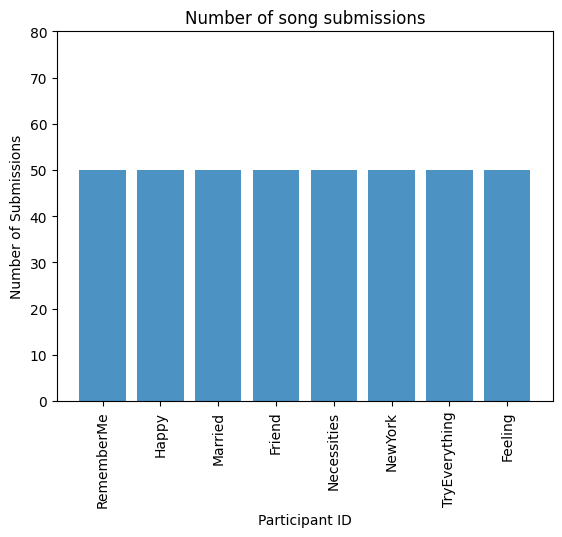

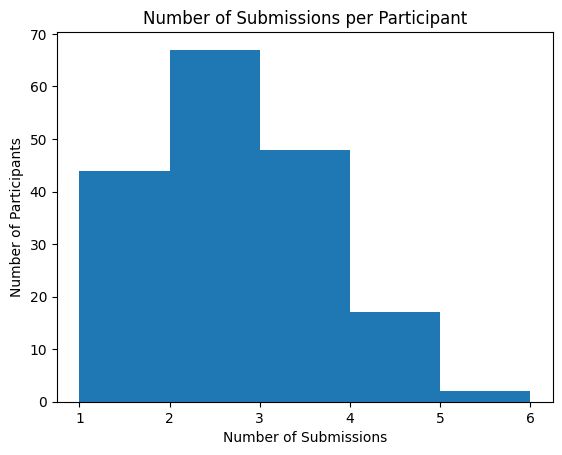

In [27]:
participant_counts = final_df["participant"].value_counts()
song_counts = final_df["song"].value_counts()

plt.bar(song_counts.index, song_counts.values, alpha=0.8)
plt.title("Number of song submissions")
plt.xlabel("Participant ID")
plt.ylabel("Number of Submissions")
plt.ylim(0,80)
plt.xticks(rotation=90)
plt.show()

plt.hist(participant_counts, bins=range(1, participant_counts.max()+2))
plt.title("Number of Submissions per Participant")
plt.xlabel("Number of Submissions")
plt.ylabel("Number of Participants")
plt.show()

Further visualisation shows that there is a discrepant submissions meaning that there is not going to be an equal number of samples per label. Understanding this we can still prevent data leakage using GroupKFold cross validation.

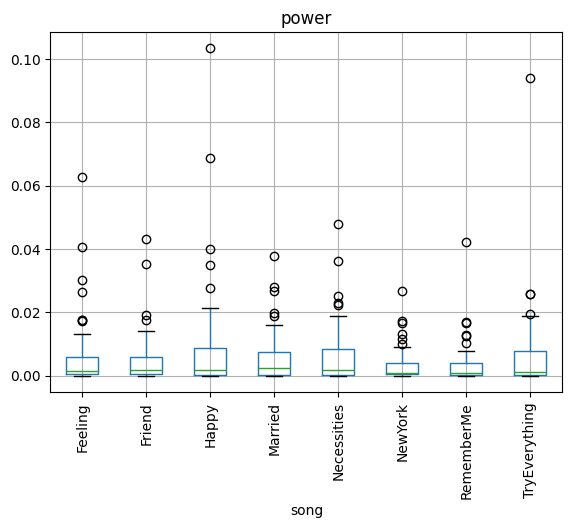

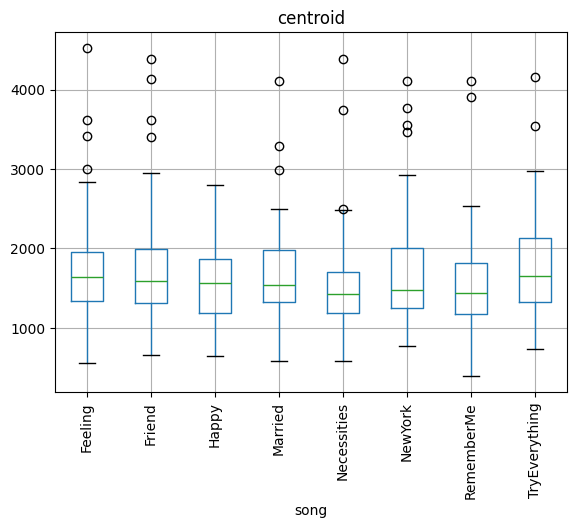

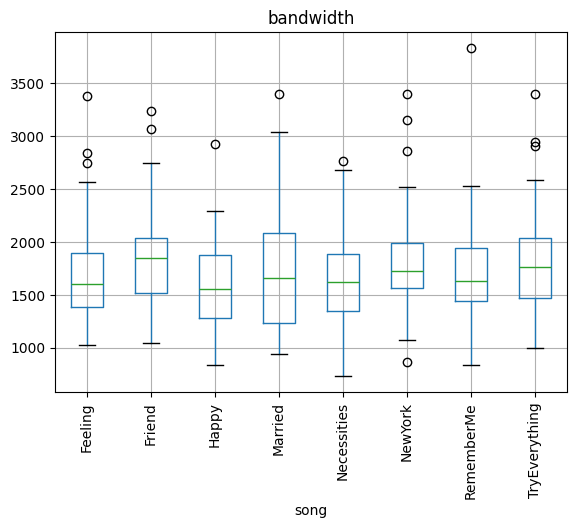

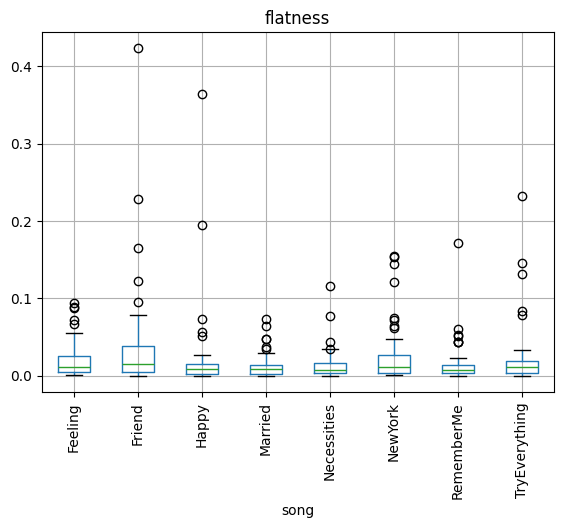

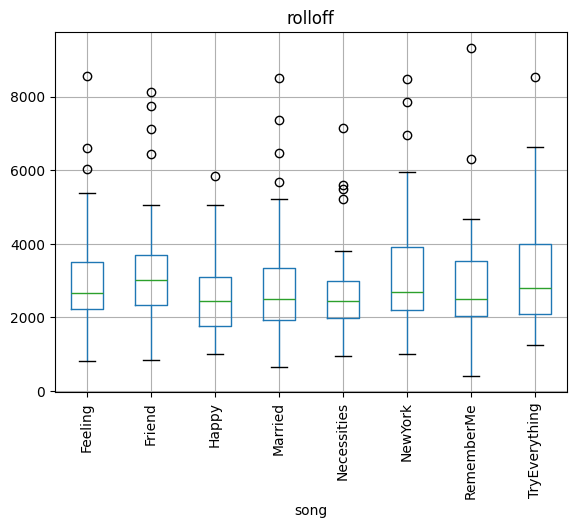

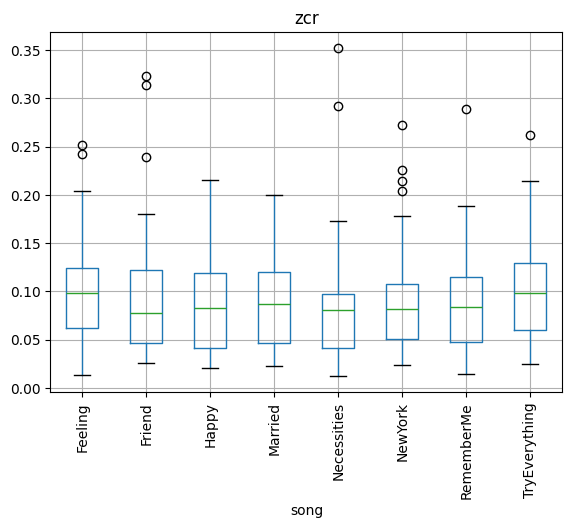

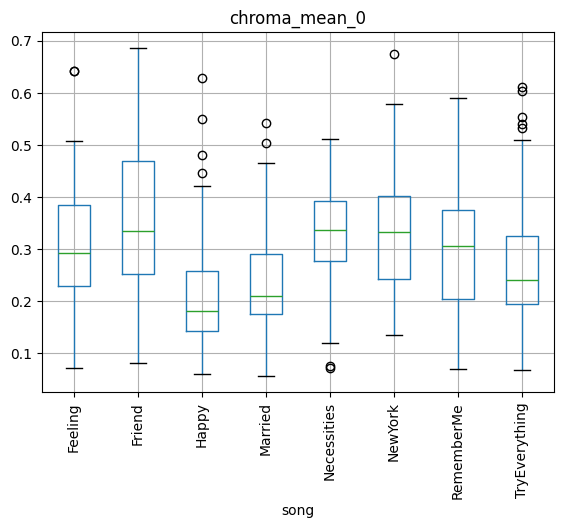

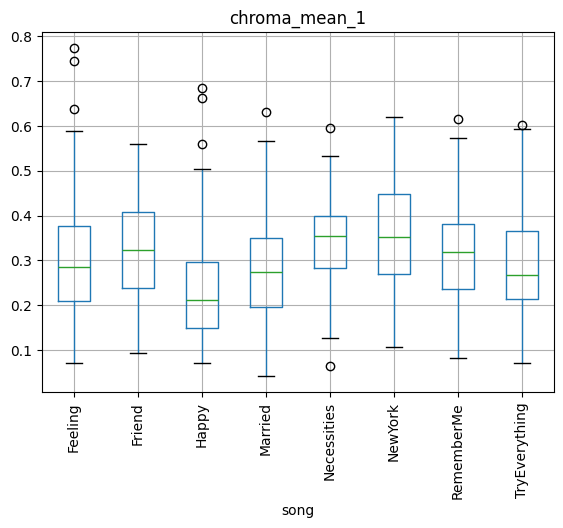

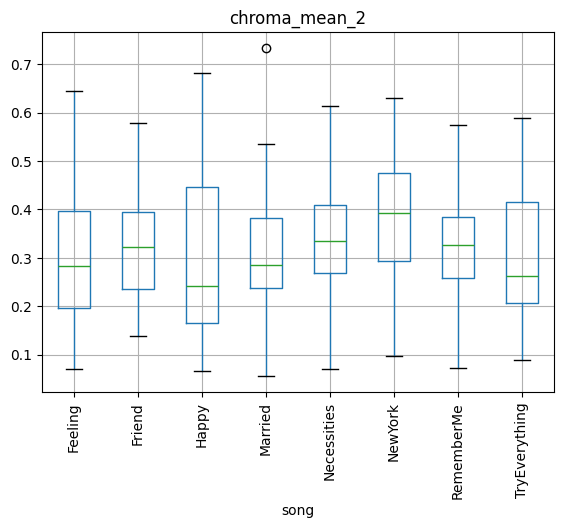

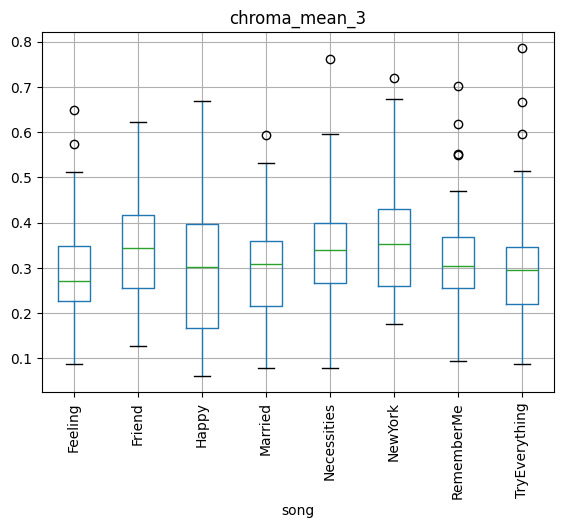

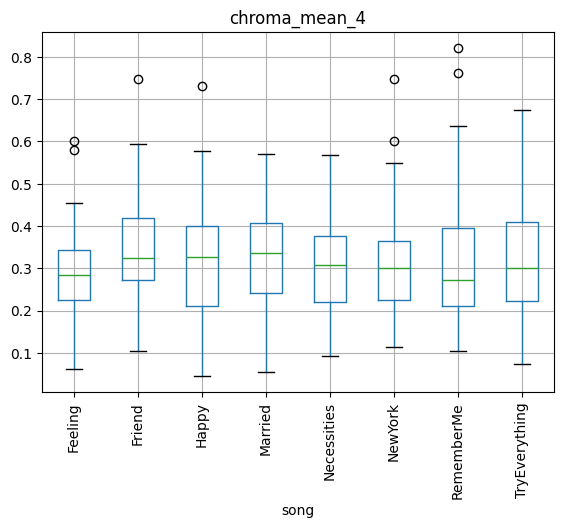

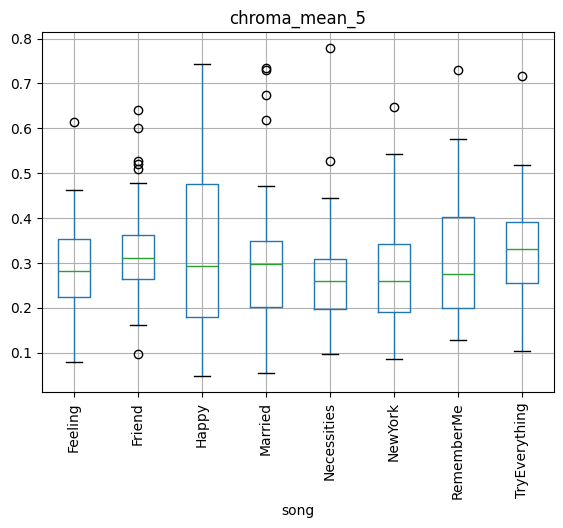

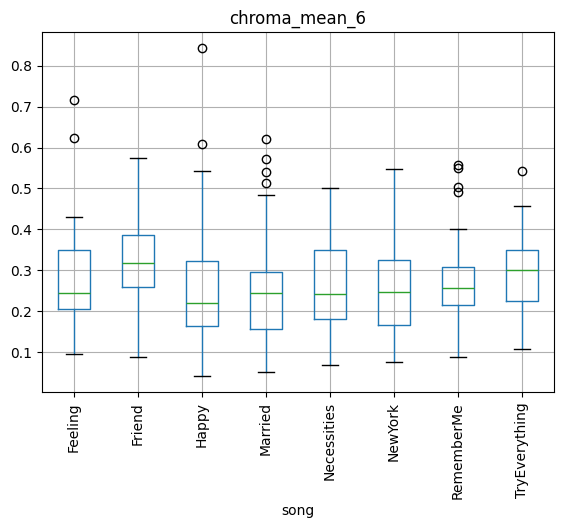

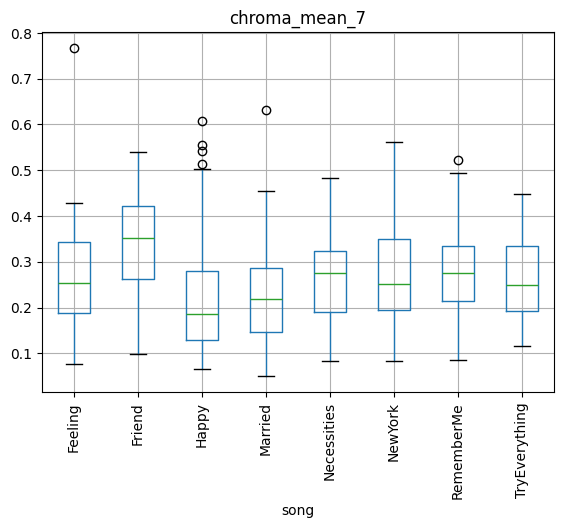

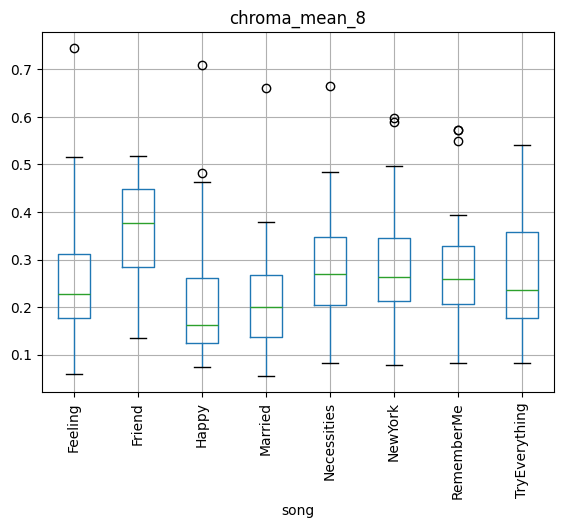

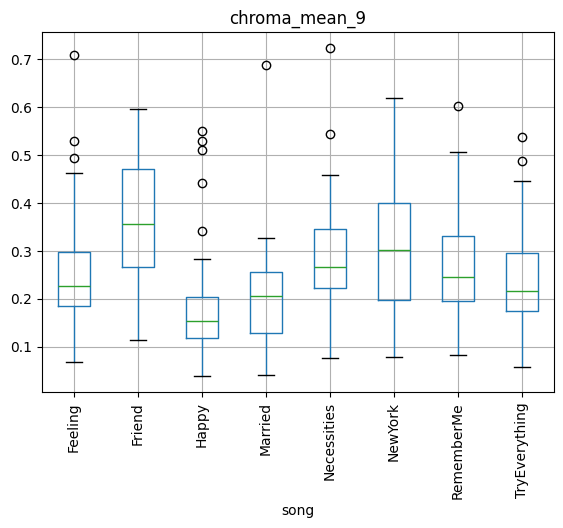

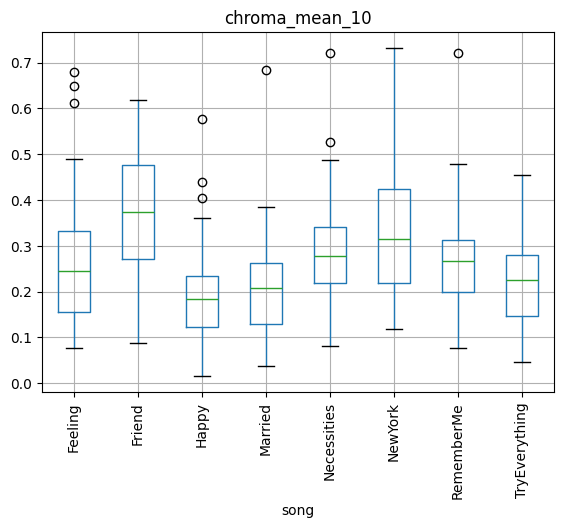

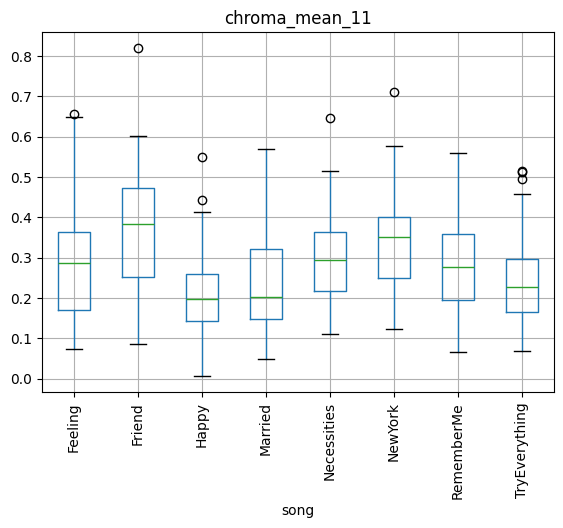

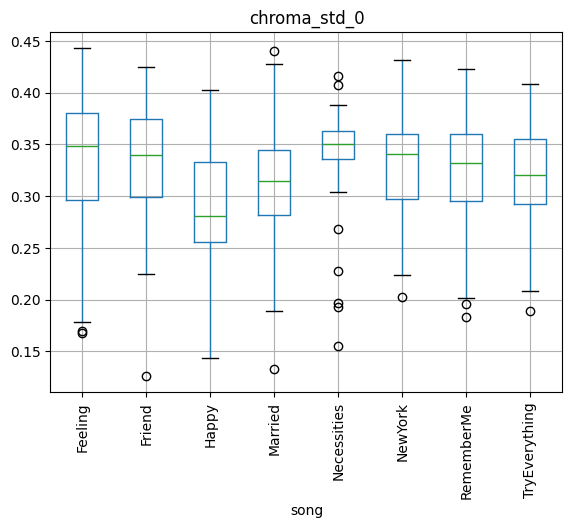

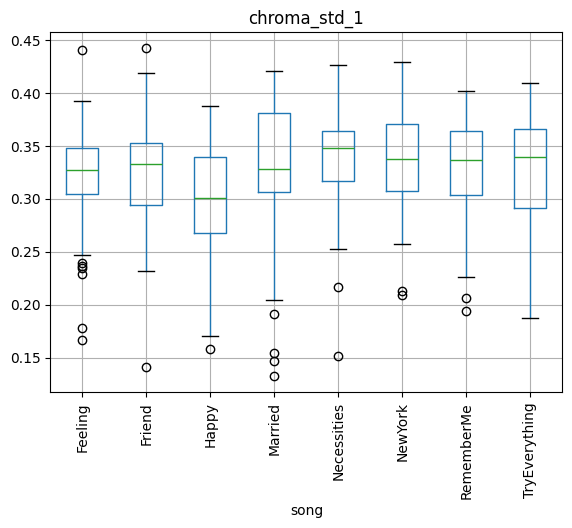

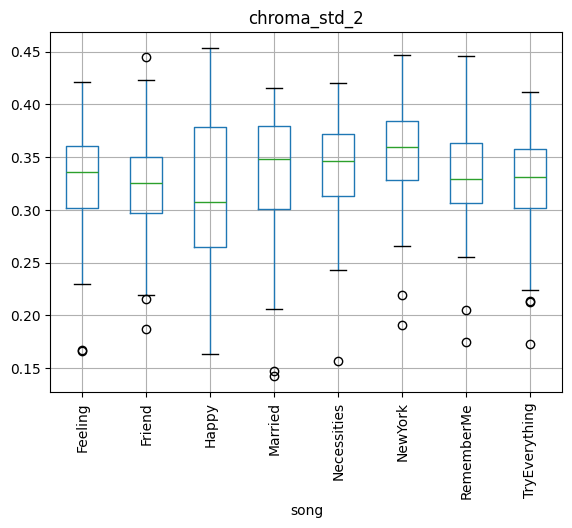

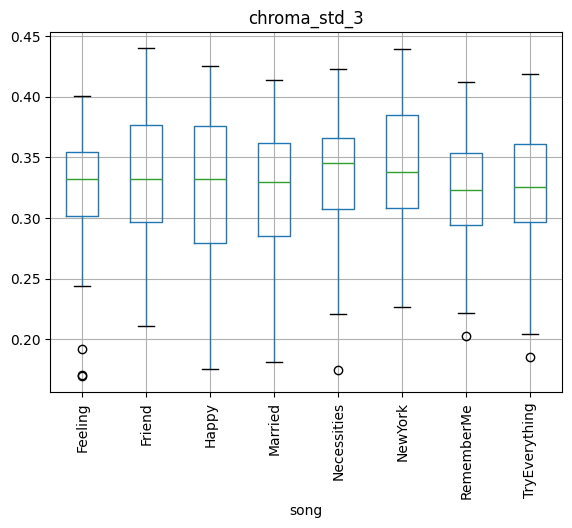

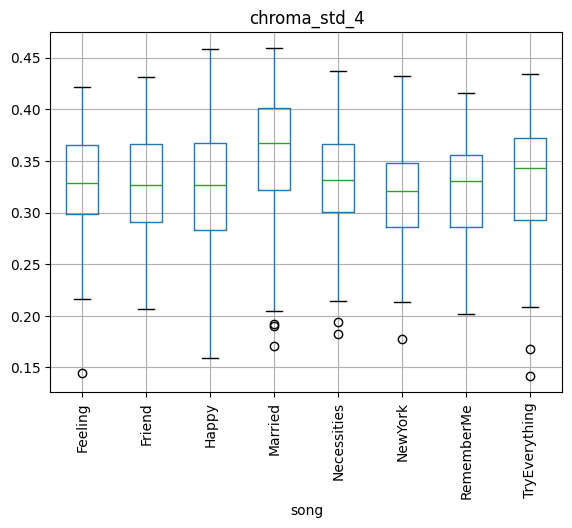

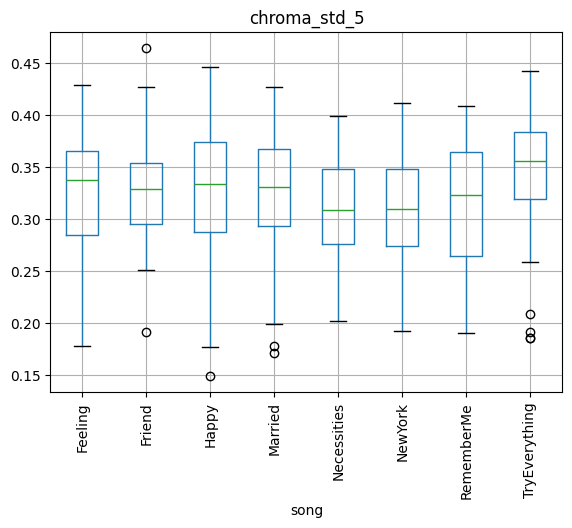

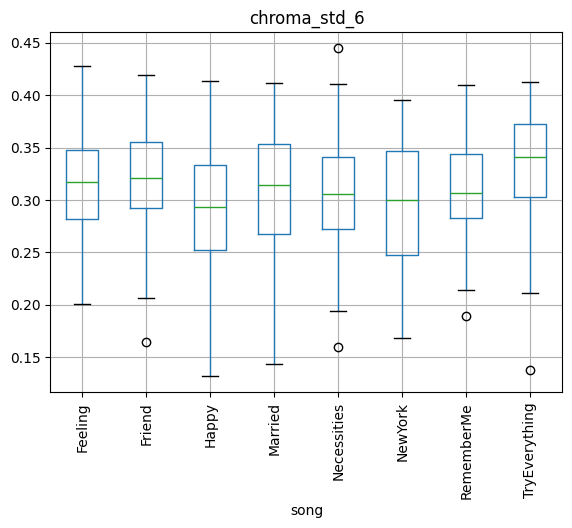

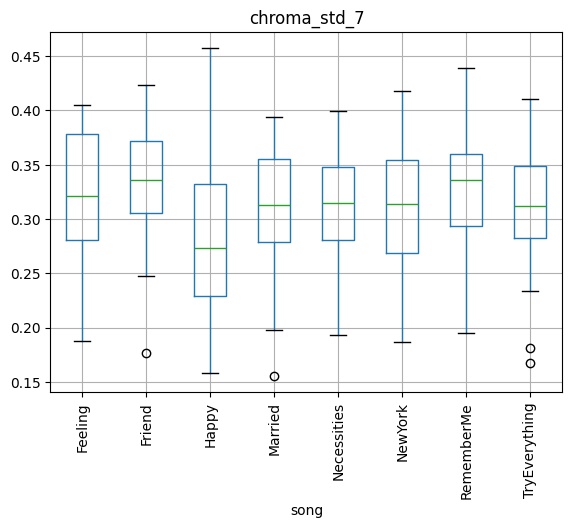

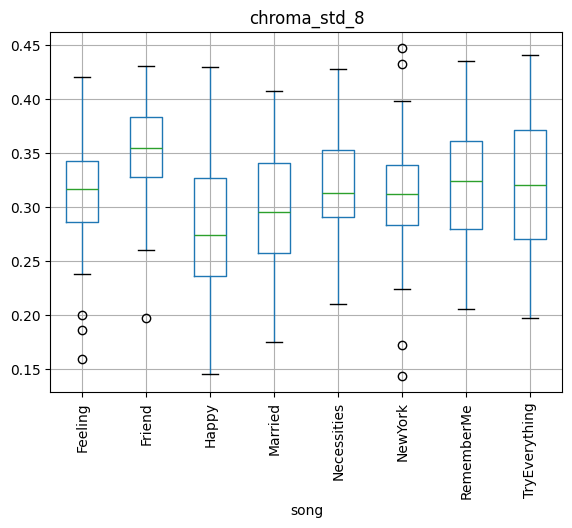

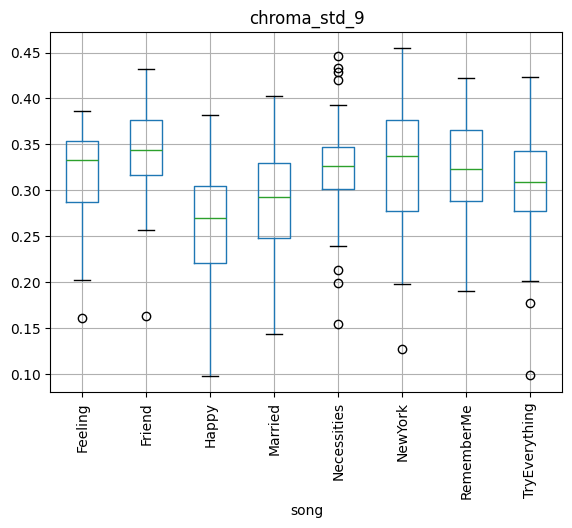

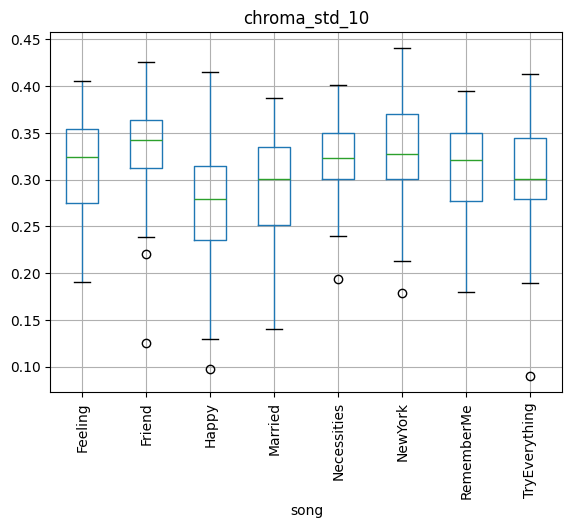

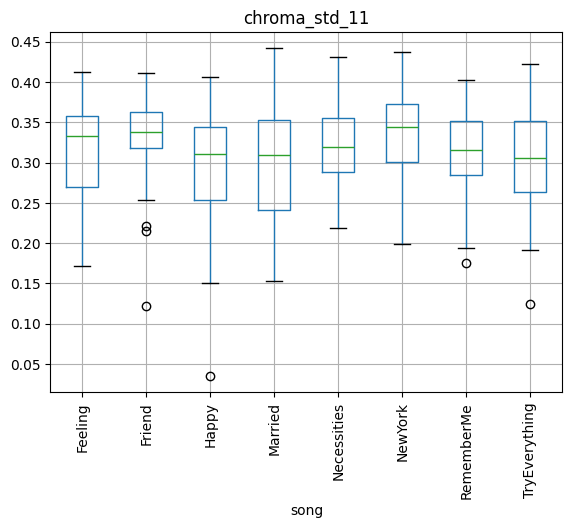

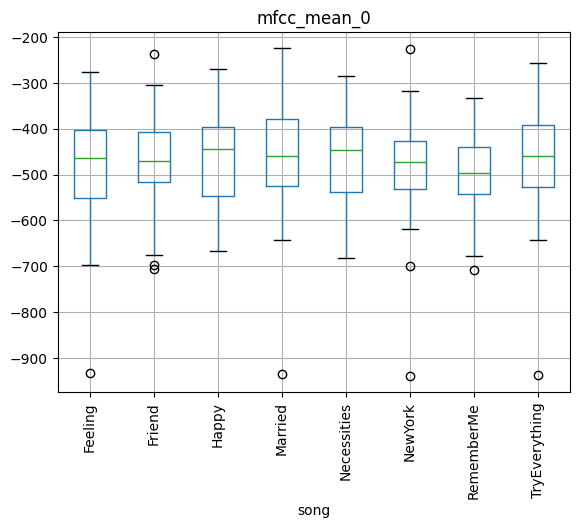

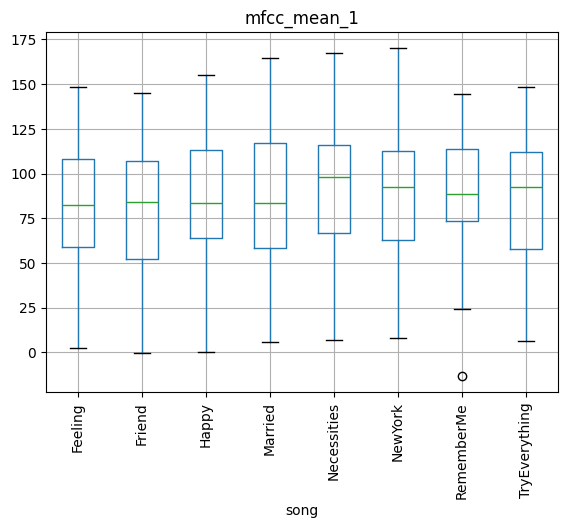

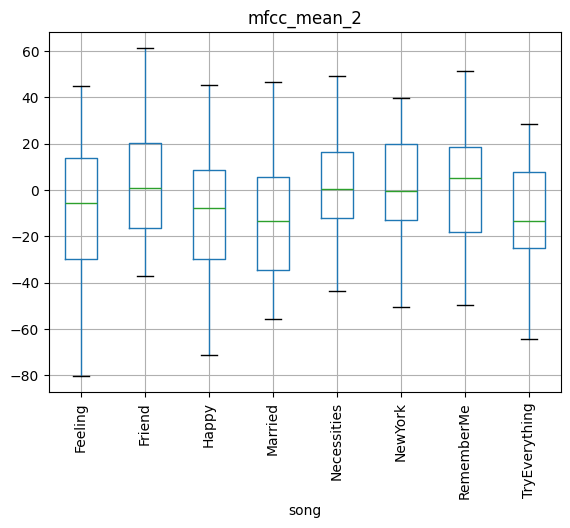

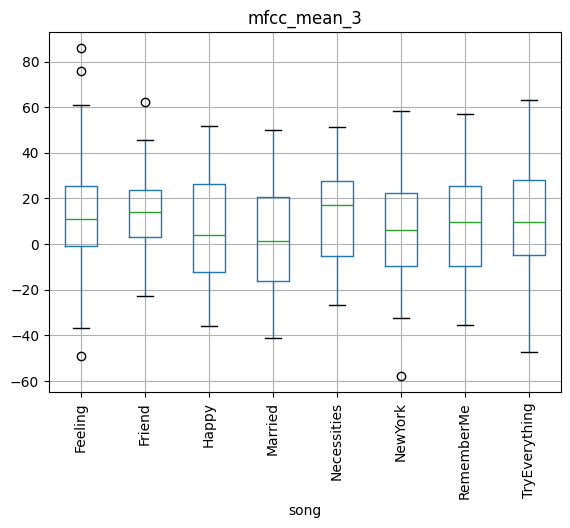

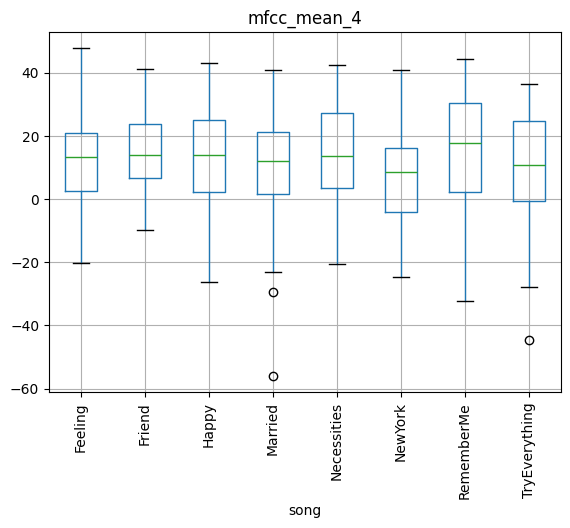

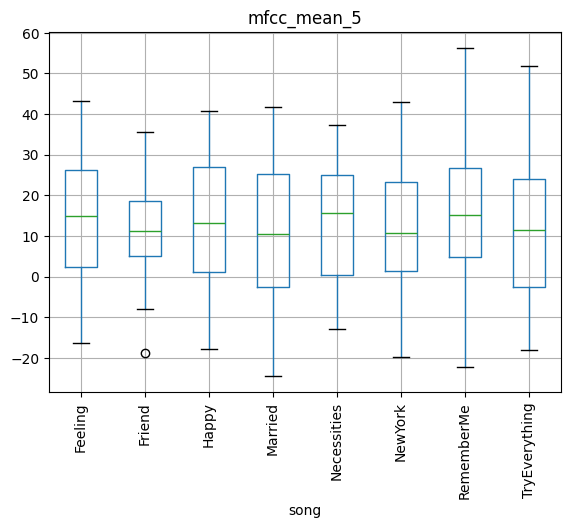

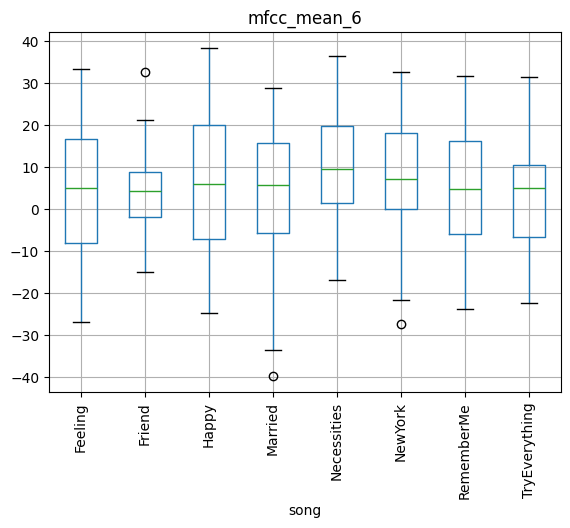

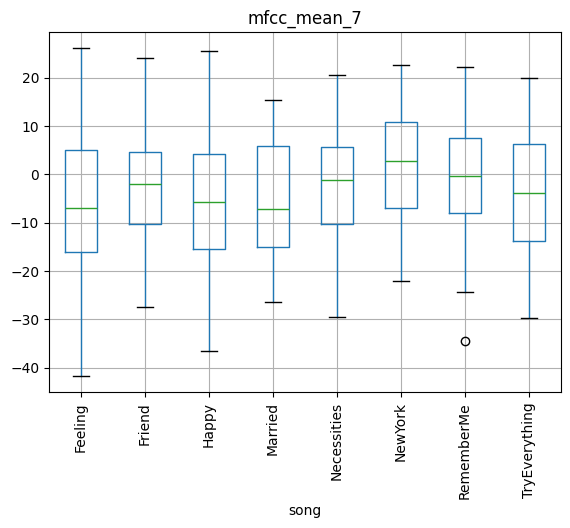

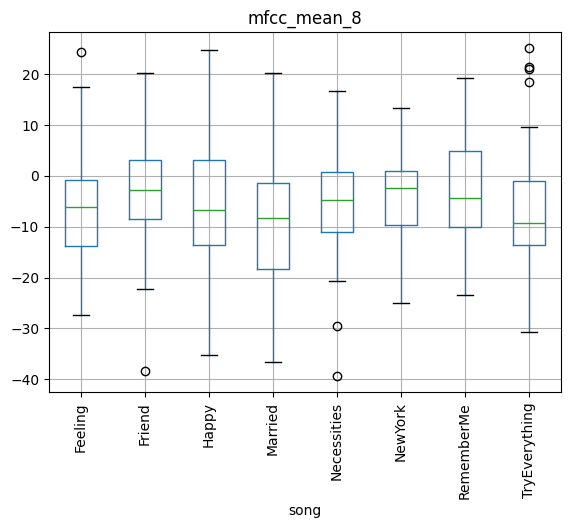

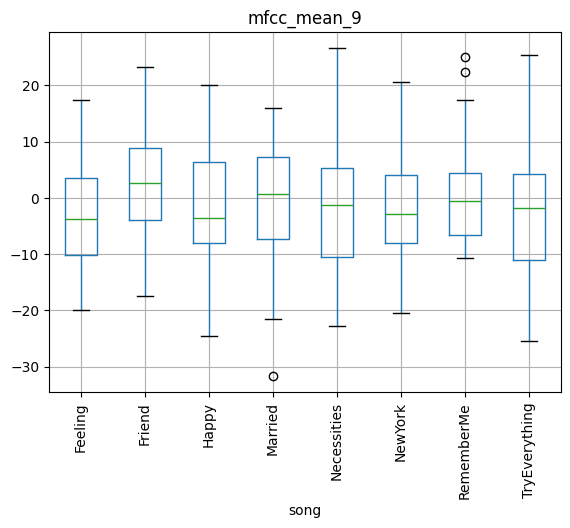

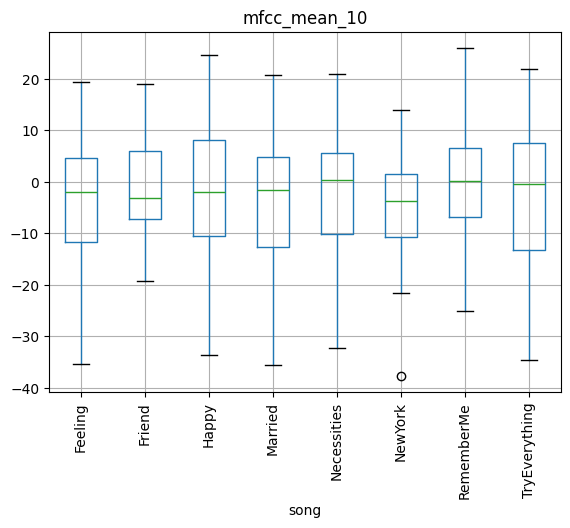

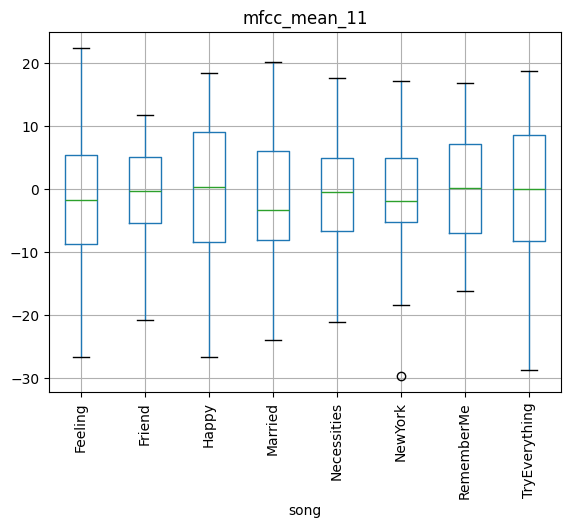

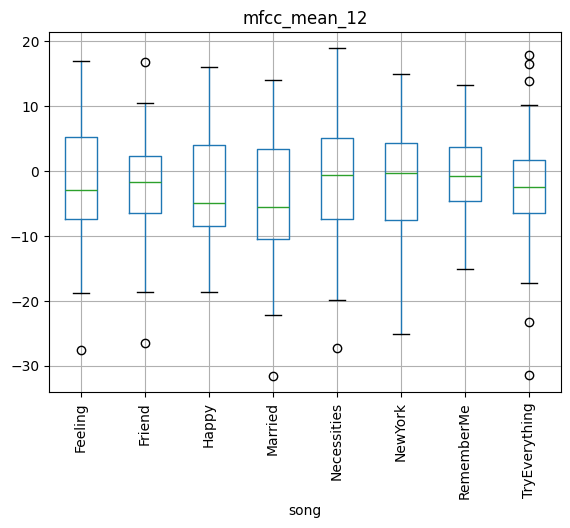

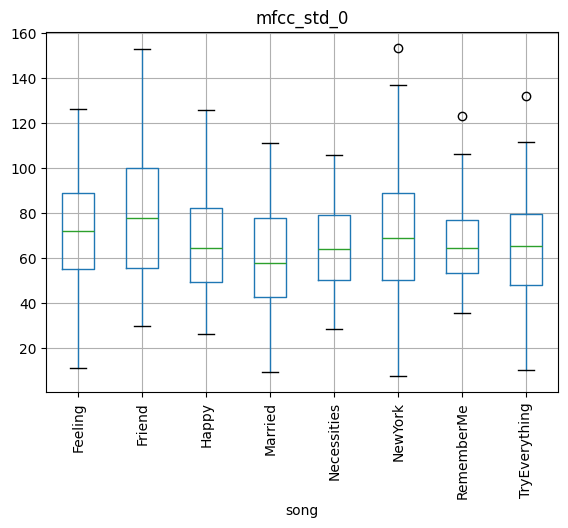

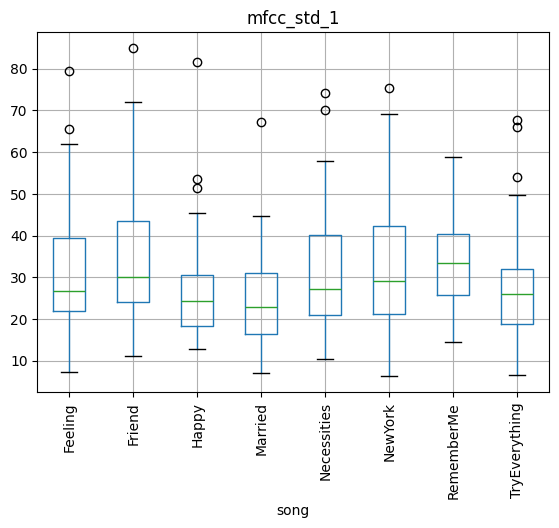

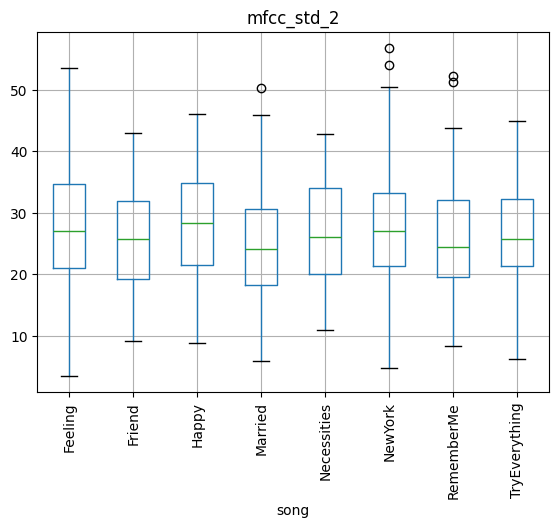

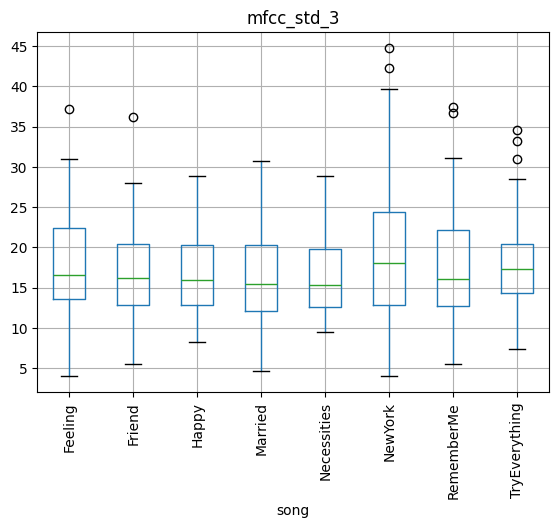

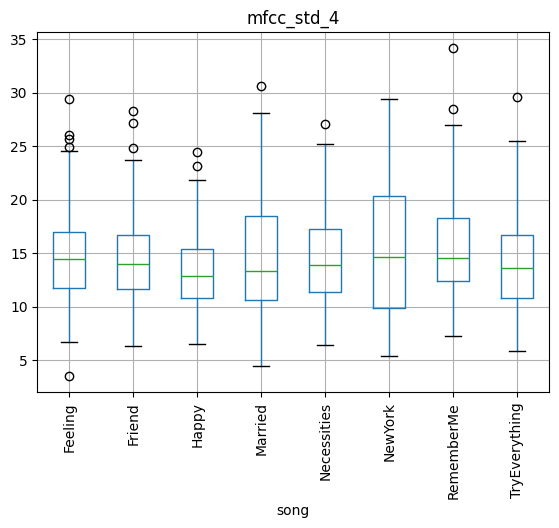

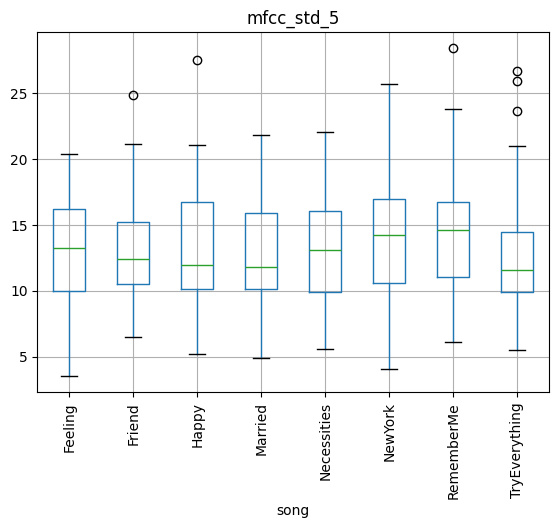

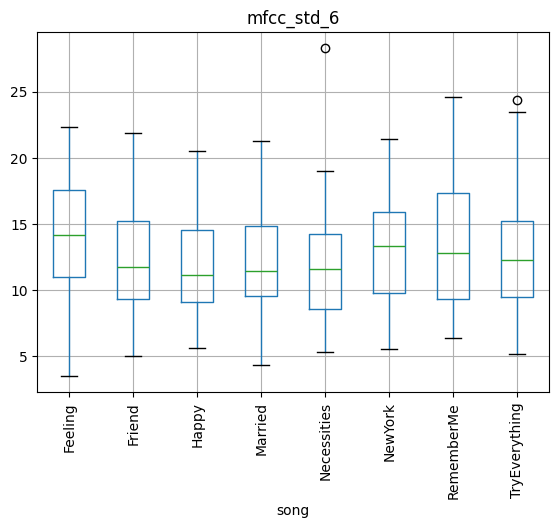

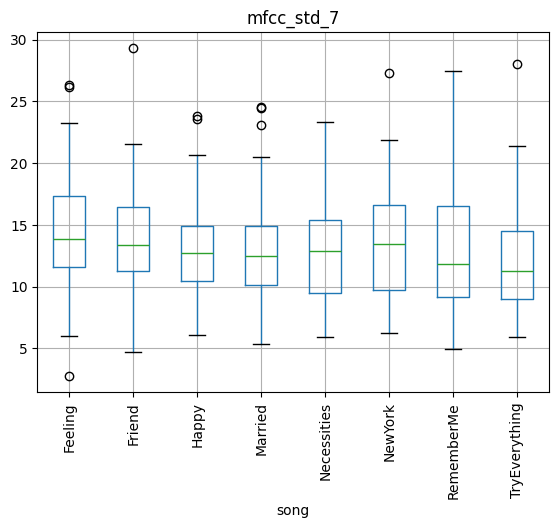

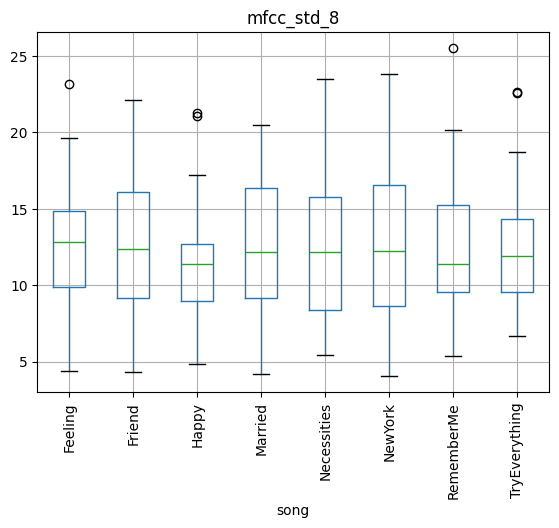

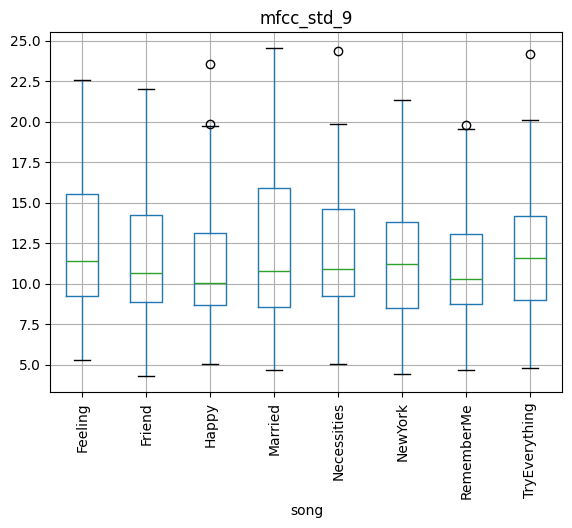

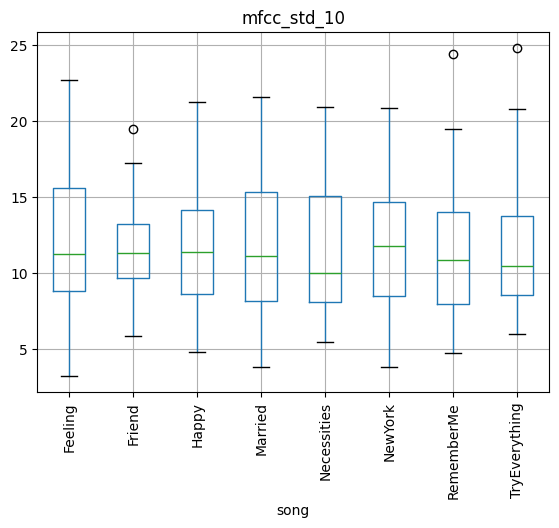

In [28]:
feature_cols = final_df.select_dtypes(include="number").columns

for col in all_features_df.columns[:-2]:  # exclude label and hum column
    final_df.boxplot(column=col, by="song")
    plt.title(col)
    plt.xticks(rotation=90)
    plt.suptitle("")
    plt.show()

Boxplot was used to see if there is any significant difference between the features per label. Allows us to make better decisions on what features might provide the most insight and what features may be hindering the model.

A few stand out features are chroms_std_9, chroma_std_11 and chroma_mean_9. Allows us to make an assumption that the model would take more heed to the melodic features.

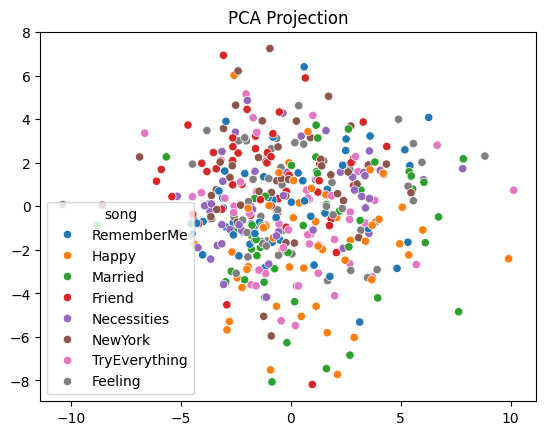

In [29]:
X = final_df.drop(["song", "interpretation", "participant"], axis=1)
y = final_df["song"]

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)
plt.title("PCA Projection")
plt.show()

The PCA plot shows that most features overlap heavy with no clear seperation between songs in the 2D space. Suggesting that the accuracy isnt going to be extremely high as there are no distinct factors about each feature.

# 5.2 Dataset B

Dataset B is a sequence-based representation of the MLEnd Hums and Whistles II dataset. Instead of summarising each recoding into statistical static features each sample is represented as a chroma sequence over time. Essentially showing the melodic progression of the audio. The dataset contains 400 samples with song labels and participant metadata.

Chroma overtime was chosen based on feature importance of the tree based data as well through listening to submisions the melodies were what was changing the most.

There is the same unbalanced as i am importing the same number of files however agin using GroupKFold cross validation prevents data leakage.

**Limitations**

Although Dataset B preserves the temporal structure, it becomes more computationally expensive to process compared to dataset A. In addition because of how sensitive it these features are they can vary based on the participants humming style.

In [30]:
rows = []

for file in files:

    y, sr = load_audio_10s(file)

    # chroma sequence over time
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    filename = os.path.basename(file).replace('.wav', '')
    parts = filename.split('_')

    participant = parts[0]
    interpretation = parts[1]
    trial = parts[2]
    song = parts[3]

    rows.append({
        "participant": participant,
        "interpretation": interpretation,
        "song": song,
        "sequence": chroma
    })

dtw_df = pd.DataFrame(rows)


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [93]:
dtw_df

,participant,interpretation,song,sequence
0,S100,whistle,Happy,"[[1.0, 1.0, 1.0, 1.0, 0.71416086, 0.8247961, 1..."
1,S101,hum,Married,"[[0.8638933, 0.75362164, 0.74310184, 1.0, 1.0,..."
2,S103,hum,RememberMe,"[[0.9404495, 1.0, 0.742903, 0.71951795, 0.9789..."
3,S100,hum,Married,"[[0.83432263, 1.0, 0.9160579, 0.87853783, 0.73..."
4,S100,whistle,RememberMe,"[[0.9636147, 0.83478737, 0.7013776, 0.71828204..."
...,...,...,...,...
395,S98,whistle,Necessities,"[[0.4872758, 0.70300794, 0.9325534, 0.48256359..."
396,S98,whistle,Happy,"[[1.0, 0.67752147, 0.31378257, 0.41809607, 0.3..."
397,S99,whistle,Happy,"[[0.0037472397, 0.00067743467, 0.00015863862, ..."
398,S99,whistle,Feeling,"[[0.0054288264, 0.47019488, 0.71486646, 0.2249..."


To explore this data set, the dominant pitch over time was visualised to see how the melodic strucure changes over time.

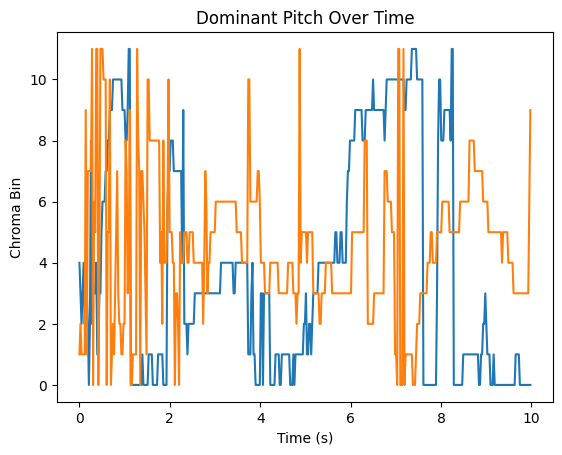

In [35]:
seq = dtw_df.iloc[0]["sequence"]
dominant_pitch = np.argmax(seq, axis=0)
times = np.arange(len(dominant_pitch)) * (10 / len(dominant_pitch))

seq_c = dtw_df.iloc[4]["sequence"]
dominant_pitch_c = np.argmax(seq_c, axis=0)
times_c = np.arange(len(dominant_pitch_c)) * (10 / len(dominant_pitch_c))


plt.plot(times, dominant_pitch)
plt.plot(times_c, dominant_pitch_c)
plt.title("Dominant Pitch Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Chroma Bin")
plt.show()

Comparing 2 labels visualy between song "Happy" and "Remember me" overtime allows breif visual analysis of how the pitches change in a time series per song.

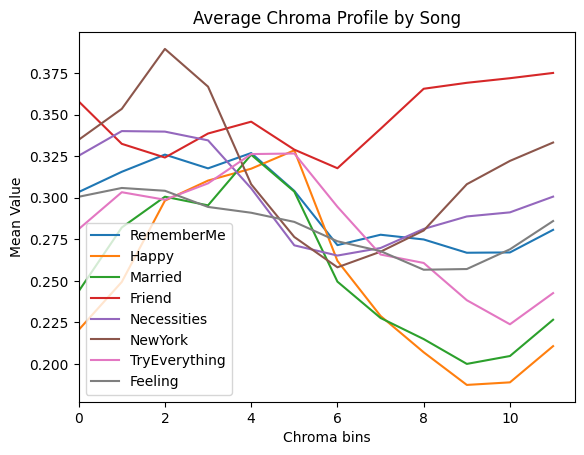

In [38]:

avg_chroma = []

for song in dtw_df["song"].unique():
    seqs = dtw_df[dtw_df["song"] == song]["sequence"]
    mean_profile = np.mean([seq.mean(axis=1) for seq in seqs], axis=0)
    avg_chroma.append(mean_profile)

avg_chroma = np.array(avg_chroma)

for i, song in enumerate(dtw_df["song"].unique()):
    plt.plot(avg_chroma[i], label=song)

plt.title("Average Chroma Profile by Song")
plt.xlabel("Chroma bins")
plt.ylabel("Mean Value")
plt.xlim(0,11.5)
plt.legend()
plt.show()

The average chroma profiles show some variation between songs however there still is substancial overlap across pitch classes. Noticably there is some seperation from bins 10-12 meaning that could be somthing to further have a look at.

# 6.1 Feature selection based on statistical and model testing

This experiment aims to improve model performance by selecting features using ANOVA (statistical significance) and feature importance (model-based relevance). By taking the intercessions of the top 30 features of both methods to create a reduced data set that will be retrained and tested with our better model

In [39]:
le = LabelEncoder() #converts song names -> numbers so it can be used later

X = final_df.drop(['song','interpretation','participant'], axis=1)
y = le.fit_transform(final_df['song'])

f_vals, p_vals = f_classif(X, y)

anova_scores = sorted(
    zip(X.columns, p_vals),
    key=lambda x: x[1]
)

In [40]:
scores_df = pd.DataFrame(anova_scores)
scores_df.columns = ["feature", "p_value"]
scores_df[:30]


,feature,p_value
0,chroma_mean_10,1.173584e-15
1,chroma_mean_9,1.354412e-14
2,chroma_mean_11,6.974175e-12
3,chroma_mean_8,1.458485e-10
4,chroma_std_9,1.709879e-08
5,chroma_mean_0,5.570597e-08
6,chroma_std_8,7.313838e-08
7,chroma_std_10,2.358609e-07
8,chroma_mean_7,1.247547e-05
9,chroma_std_0,5.978791e-04


What we the ANOVA test is a test that is great for multiple features and evaluates wether there is a statistical significant difference which is measured through the p value. Wether it is judged as being signifcantly different is if the p value is under 0.05. From the ouput the top 21 features are all deemed statistically significantly different.

The reason why i didnt disclude them as it is still a range of significance and the ANOVA score is not a be all end all test but something that provides us with more information, to make further decisions.

<Axes: >

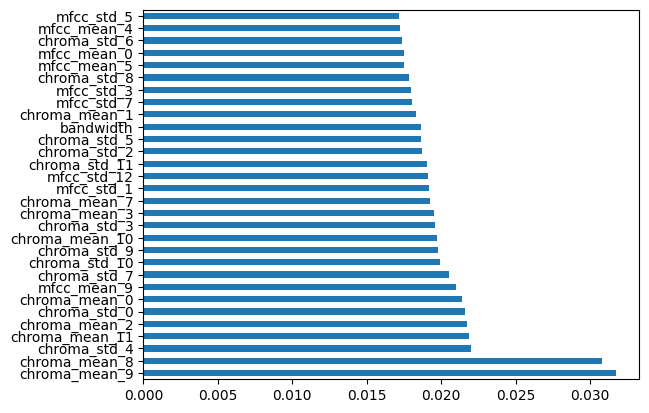

In [41]:
feature_importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(30)
top_features.plot(kind='barh')

Feature importance was computed from the best tree model and for better visualisation the data was plotted on a horizontal bar graph. Looking at the data Chroma_mean_8 and 9 have a significantly higher importance to the tree model compared to their counterparts.

In [45]:
top30_impotance = feature_importances.nlargest(30)
top30_anova = scores_df.nsmallest(30, "p_value")["feature"]

common_features = top30_impotance.index.intersection(top30_anova)
common_features

Index(['chroma_mean_9', 'chroma_mean_8', 'chroma_std_4', 'chroma_mean_11',
       'chroma_mean_2', 'chroma_std_0', 'chroma_mean_0', 'chroma_std_7',
       'chroma_std_10', 'chroma_std_9', 'chroma_mean_10', 'chroma_mean_3',
       'chroma_mean_7', 'mfcc_std_1', 'chroma_std_11', 'chroma_std_2',
       'chroma_std_5', 'chroma_mean_1', 'chroma_std_8', 'chroma_std_6'],
      dtype='object')

Using feature importance and anova score the features that appeared over both tests was extracted.

Having a look at all the extracted features they all involve the melodic summaries of each song.

In [74]:

tree_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.03,
    max_depth=5,
    n_estimators=200,
    subsample=0.8,
    eval_metric="mlogloss",
    random_state=42
)
X_selected = final_df[common_features].copy()
y = le.fit_transform(final_df['song'])

all_true = []
all_pred = []

print("Class mapping:")
for i, song in enumerate(le.classes_):
    print(f"{i} -> {song}")

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_selected, y, groups=final_df["participant"]), 1
):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    tree_model.fit(X_train, y_train)
    y_pred = tree_model.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

print(line)

print("Accuracy:", accuracy_score(all_true, all_pred))
print(classification_report(all_true, all_pred, target_names=le.classes_))


Class mapping:
0 -> Feeling
1 -> Friend
2 -> Happy
3 -> Married
4 -> Necessities
5 -> NewYork
6 -> RememberMe
7 -> TryEverything
Accuracy: 0.28
               precision    recall  f1-score   support

      Feeling       0.29      0.24      0.26        50
       Friend       0.38      0.50      0.43        50
        Happy       0.35      0.42      0.38        50
      Married       0.19      0.20      0.20        50
  Necessities       0.30      0.28      0.29        50
      NewYork       0.27      0.28      0.28        50
   RememberMe       0.16      0.14      0.15        50
TryEverything       0.24      0.18      0.20        50

     accuracy                           0.28       400
    macro avg       0.27      0.28      0.27       400
 weighted avg       0.27      0.28      0.27       400



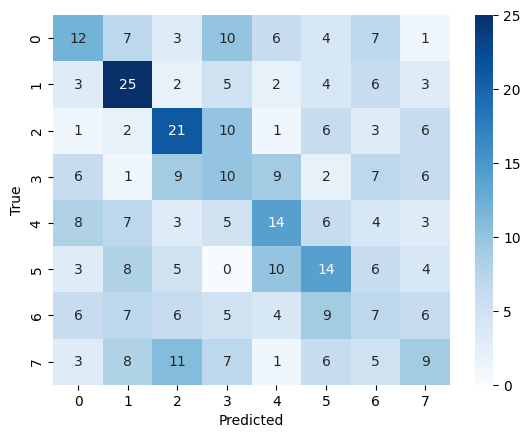

In [75]:
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

The confusion matrix shows that while some classes are predicted whell alot of classes are heavilly mixed accross categories.

The results show a small but consistent improvement after feature selection compared to the full featured dataset. The accuracy increased from 0.26 with the original features and hyperperameters to 0.28. Indicates that the removal of some noisy features allowed the model to focus on more informative patterns.

This result tells us that there were redundant features that negatively impacted model performance. By filtering features based on statistical significance allowing the model to generalise slightly better.

On the other hand although there was an increase in accuracy, the increase was marginal. Performance across several classes, such as "Remember me" which is 0.16 still being higher then the benchmark of 0.125 of random guessing.

# 6.2 Different approach - DTW Model - will distance based classifying work on dataset B?

Dynamic Time Warping (DTW) was applied as a sequence-based classification method to directly compare temporal audio signals. Unlike feature-based models such as XGBoost that rely on extracted statistical features, DTW measures similarity between the whole sequences. This allows the model to capture time dependent patterns and variations. A KNN classifier with a precomputed DTW distance matrix was used. Allowing each sample to be classified on its similarity to others in the dataset.

GroupKFold was used to keep the validation procedures the same, this allows for better comparison.

In [52]:
le = LabelEncoder()
y = le.fit_transform(dtw_df["song"])
groups = dtw_df["participant"]

gkf = GroupKFold(n_splits=5)

In [53]:
def dtw_distance(seq1, seq2):
    """
    seq1, seq2 shape: (12, time_steps)
    returns a normalised DTW distance
    """
    D, wp = dtw(seq1, seq2, subseq=False)
    return D[-1, -1] / len(wp)

The DTW distance was normalised by the length of the warping path to ensure taht distance values are comparable across sequences of different lengths. Without normalisation, longer sequences would automatically have larger values which would bias the model.

In [54]:
def build_dtw_matrix(train_sequences, test_sequences=None):
    """
    If test_sequences is None:
        returns train-vs-train distance matrix
    Else:
        returns test-vs-train distance matrix
    """
    if test_sequences is None:
        n = len(train_sequences)
        dist_matrix = np.zeros((n, n))

        for i in range(n):
            for j in range(i, n):
                dist = dtw_distance(train_sequences[i], train_sequences[j])
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist

        return dist_matrix

    else:
        n_test = len(test_sequences)
        n_train = len(train_sequences)
        dist_matrix = np.zeros((n_test, n_train))

        for i in range(n_test):
            for j in range(n_train):
                dist_matrix[i, j] = dtw_distance(test_sequences[i], train_sequences[j])

        return dist_matrix

This function allows training to be compared with training and test data to be compared with test. It is then used by the model KNN.

In [55]:
dtw_models = {
    "DTW_KNN_3": KNeighborsClassifier(
        n_neighbors=3,
        weights="distance",
        metric="precomputed"
    )
}

#Made it a dict because i wanted to test multiple models but its just really slow so maybe if i have more time i can run more models

In [56]:
def evaluate_dtw_models(model_dict, dtw_df, y, groups, label_encoder):
    line = "=" * 50

    all_acc = {name: [] for name in model_dict}
    all_true = {name: [] for name in model_dict}
    all_pred = {name: [] for name in model_dict}
    trained_models = {}

    for fold, (train_idx, test_idx) in enumerate(gkf.split(dtw_df, y, groups=groups), 1):
        print(f"Fold {fold} running...")

        train_sequences = dtw_df.iloc[train_idx]["sequence"].tolist()
        test_sequences = dtw_df.iloc[test_idx]["sequence"].tolist()

        y_train, y_test = y[train_idx], y[test_idx]

        # Build DTW distance matrices
        X_train_dtw = build_dtw_matrix(train_sequences)
        X_test_dtw = build_dtw_matrix(train_sequences, test_sequences)

        for name, model in model_dict.items():
            model.fit(X_train_dtw, y_train)
            y_pred = model.predict(X_test_dtw)

            acc = accuracy_score(y_test, y_pred)

            all_acc[name].append(acc)
            all_true[name].extend(y_test)
            all_pred[name].extend(y_pred)

            trained_models[name] = model

    mean_acc = {name: np.mean(scores) for name, scores in all_acc.items()}
    sorted_acc = sorted(mean_acc.items(), key=lambda x: x[1], reverse=True)

    best_name, best_score = sorted_acc[0]

    print(f"\n{line}")
    print("DTW Distance-Based Models")
    print(line)

    print("Class mapping:")
    for i, song in enumerate(label_encoder.classes_):
        print(f"{i} -> {song}")

    print(line)
    print(f"Best model: {best_name}")
    print(f"Mean CV Accuracy: {best_score:.4f}")
    print(classification_report(all_true[best_name], all_pred[best_name], target_names=label_encoder.classes_))

    return mean_acc, all_pred, trained_models, sorted_acc

In [59]:
dtw_acc, dtw_preds, dtw_trained_models, dtw_sorted = evaluate_dtw_models(
    dtw_models, dtw_df, y, groups, le
)

Fold 1 running...
Fold 2 running...
Fold 3 running...
Fold 4 running...
Fold 5 running...

DTW Distance-Based Models
Class mapping:
0 -> Feeling
1 -> Friend
2 -> Happy
3 -> Married
4 -> Necessities
5 -> NewYork
6 -> RememberMe
7 -> TryEverything
Best model: DTW_KNN_3
Accuracy: 0.3250
               precision    recall  f1-score   support

      Feeling       0.22      0.25      0.24         8
       Friend       0.60      0.25      0.35        12
        Happy       0.36      0.50      0.42        10
      Married       0.38      0.55      0.44        11
  Necessities       0.57      0.40      0.47        10
      NewYork       0.40      0.25      0.31         8
   RememberMe       0.18      0.38      0.24         8
TryEverything       0.14      0.08      0.10        13

     accuracy                           0.33        80
    macro avg       0.36      0.33      0.32        80
 weighted avg       0.36      0.33      0.32        80



Side note running all 5 folds and presenting it was making my computer crash so i only plotted the last one this does not give me the full evaluation on the model but it does give a direction

The DTW-based model achieved an accuracy of 0.33 which is similar to the performance of the feature based models. Allowing the inference that temporal sequence similarity alone can be sufficient to capture meaningful patterns of data.

Looking at the performance across classes. "Married" (0.44) and "Necessities" (0.47) showed the best f1 score. Happy performed relatively well with a f1 score of 0.42. Looking at the labels with the lowest performance, "Try Everythin" had a terrible score of 0.10 being less than the benchmark of 0.125, which is followed by "Feeling" (0.24) and "Remember Me" (0.24).

Performance in this model had a lower variance accross all models compared to XGBoost as well as the model ensumble suggesting that even though this model isnt the most accurate it is more consistant compared to the better model.



# 7 Conclusion

This report explored multiple approaches to audio-based song classification. Including feature based models (XGBoost), and sequence based methods (DTW) as well as other ensemble approaches. Across experiments performance remained similar with accuracies ranging around 0.28-0.33, showing that even though there was an initial increase from the previous modling in 4.2 it was very minimal implying the task is inherently challenging.

The main limitation appears to be the data representation rather than the model choice. This is because feature selection only provided a small improvement as well as looking at the PCA as well as the the Average Chroma Profile by Song you can see alot of overlap which explains the difficulty to separate the classes by the extracted features.

Some direct improvements to the model that would allow for an increased accuracy would be:
* Finding more advance features in the librosa libary such as delta MFCC and others.
* Running a brute force approach and iterating everything ever and over until you find the best combination (may result in overfitting and would use alot of compute)
* Larger dataset

Another key factor to take on is maybe to reduce the number of folds to 3 to avoid computational overlaod as I had a few issues later on running 5 folds.

However, to improve the predictions based on the model we have developed a probilistic-based ensemble can be introduced which combines the best 2 models XGBoost and DTW could be explored. The DTW performance was comparable to XGBoost but the accuracy of both is not sufficent on their own. Notably, DTW showed stronger recall on classes such as "Married", "Necessities" and "RememberMe" suggesting that temporal patterns are particularly important for these songs, whereas XGBoost performed better on more feature-distinct classes like "Happy" and "Friend". The probability method computes how confident the model will be. As DTW is the more accurate model so we start with that and if the confidence falls below a certain threshold then DTW's prediction would be limited.

Creating a confidence approach would likely allow the predictions to be more accurate have less variance.

# 8 References

Libraries Used
* NumPy – numerical operations and array handling
* pandas – data manipulation and DataFrame operations
* Matplotlib – data visualisation
* Seaborn – enhanced visualisations
* scikit-learn – model training, evaluation, preprocessing, PCA, and feature selection
* XGBoost – implementation of the XGBoost classifier
* librosa – audio processing, feature extraction (MFCC, chroma) and DTW
* tqdm – progress tracking during loops
* IPython – audio playback and notebook interaction